<a href="https://colab.research.google.com/github/rlaharira/Tourism-Experience-Analytics/blob/main/Tourism_Experience_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Tourism Experience Analytics
# Step 1: Environment Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Environment is working!")

Pandas version: 2.2.3
NumPy version: 2.1.3
Environment is working!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving User.xlsx to User.xlsx
Saving Type.xlsx to Type.xlsx
Saving Transaction.xlsx to Transaction.xlsx
Saving Region.xlsx to Region.xlsx
Saving Mode.xlsx to Mode.xlsx
Saving Item.xlsx to Item.xlsx
Saving Country.xlsx to Country.xlsx
Saving Continent.xlsx to Continent.xlsx
Saving Additional_Data_for_Attraction_Sites-20260909T085408Z-1-001.zip to Additional_Data_for_Attraction_Sites-20260909T085408Z-1-001.zip
Saving City (1).xlsx to City (1).xlsx
Saving City.xlsx to City.xlsx
Saving Updated_Item.xlsx to Updated_Item.xlsx


In [ ]:
import os

print("Files in Colab:\n")

for file in os.listdir('/content'):
    print(file)

Files in Colab:

.config
City.xlsx
City (1).xlsx
User.xlsx
Mode.xlsx
Item.xlsx
Type.xlsx
Transaction.xlsx
Continent.xlsx
Country.xlsx
Additional_Data_for_Attraction_Sites-20260909T085408Z-1-001.zip
Updated_Item.xlsx
User.xlsx - User.pdf
Region.xlsx
sample_data


In [ ]:
import pandas as pd
import os

# Find all Excel files
excel_files = [
    f for f in os.listdir('/content')
    if f.lower().endswith('.xlsx')
]

print("Excel files found:", len(excel_files))

for f in excel_files:
    print("-", f)

Excel files found: 11
- City.xlsx
- City (1).xlsx
- User.xlsx
- Mode.xlsx
- Item.xlsx
- Type.xlsx
- Transaction.xlsx
- Continent.xlsx
- Country.xlsx
- Updated_Item.xlsx
- Region.xlsx


In [ ]:
datasets = {}

for file in excel_files:
    file_path = '/content/' + file

    try:
        df = pd.read_excel(file_path)
        datasets[file] = df
        print(f"{file}: {df.shape[0]} rows × {df.shape[1]} columns")
    except Exception as e:
        print(f"Could not read {file}: {e}")

City.xlsx: 9143 rows × 3 columns
City (1).xlsx: 9143 rows × 3 columns
User.xlsx: 33530 rows × 5 columns
Mode.xlsx: 6 rows × 2 columns
Item.xlsx: 30 rows × 5 columns
Type.xlsx: 17 rows × 2 columns
Transaction.xlsx: 52930 rows × 7 columns
Continent.xlsx: 6 rows × 2 columns
Country.xlsx: 165 rows × 3 columns
Updated_Item.xlsx: 1698 rows × 5 columns
Region.xlsx: 22 rows × 3 columns


In [ ]:
for file, df in datasets.items():
    print("\n" + "="*60)
    print(file)
    print("="*60)
    print("Columns:")
    print(list(df.columns))


City.xlsx
Columns:
['CityId', 'CityName', 'CountryId']

City (1).xlsx
Columns:
['CityId', 'CityName', 'CountryId']

User.xlsx
Columns:
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

Mode.xlsx
Columns:
['VisitModeId', 'VisitMode']

Item.xlsx
Columns:
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Type.xlsx
Columns:
['AttractionTypeId', 'AttractionType']

Transaction.xlsx
Columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Continent.xlsx
Columns:
['ContinentId', 'Continent']

Country.xlsx
Columns:
['CountryId', 'Country', 'RegionId']

Updated_Item.xlsx
Columns:
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Region.xlsx
Columns:
['Region', 'RegionId', 'ContinentId']


In [ ]:
for file, df in datasets.items():
    print("\n" + "="*60)
    print(file)
    print("="*60)
    display(df.head())


City.xlsx


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3



City (1).xlsx


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3



User.xlsx


...

,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1
3,3,Rwanda,1
4,4,Ethiopia,2



Updated_Item.xlsx


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak



Region.xlsx


,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1
3,North Africa,3,1
4,Southern Africa,4,1


In [ ]:
for file, df in datasets.items():
    print("\n" + "="*60)
    print(file)
    print("="*60)

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values ✅")
    else:
        print(missing)


City.xlsx
CityName    1
dtype: int64

City (1).xlsx
CityName    1
dtype: int64

User.xlsx
CityId    4
dtype: int64

Mode.xlsx
No missing values ✅

Item.xlsx
No missing values ✅

Type.xlsx
No missing values ✅

Transaction.xlsx
No missing values ✅

Continent.xlsx
No missing values ✅

Country.xlsx
No missing values ✅

Updated_Item.xlsx
No missing values ✅

Region.xlsx
No missing values ✅


In [ ]:
for file, df in datasets.items():
    print(f"{file}: {df.duplicated().sum()} duplicate rows")

City.xlsx: 0 duplicate rows
City (1).xlsx: 0 duplicate rows
User.xlsx: 0 duplicate rows
Mode.xlsx: 0 duplicate rows
Item.xlsx: 0 duplicate rows
Type.xlsx: 0 duplicate rows
Transaction.xlsx: 0 duplicate rows
Continent.xlsx: 0 duplicate rows
Country.xlsx: 0 duplicate rows
Updated_Item.xlsx: 0 duplicate rows
Region.xlsx: 0 duplicate rows


In [ ]:
for file, df in datasets.items():
    print("\n" + "="*60)
    print(file)
    print("="*60)
    print(df.dtypes)


City.xlsx
CityId        int64
CityName     object
CountryId     int64
dtype: object

City (1).xlsx
CityId        int64
CityName     object
CountryId     int64
dtype: object

User.xlsx
UserId           int64
ContinentId      int64
RegionId         int64
CountryId        int64
CityId         float64
dtype: object

Mode.xlsx
VisitModeId     int64
VisitMode      object
dtype: object

Item.xlsx
AttractionId          int64
AttractionCityId      int64
AttractionTypeId      int64
Attraction           object
AttractionAddress    object
dtype: object

Type.xlsx
AttractionTypeId     int64
AttractionType      object
dtype: object

Transaction.xlsx
TransactionId    int64
UserId           int64
VisitYear        int64
VisitMonth       int64
VisitMode        int64
AttractionId     int64
Rating           int64
dtype: object

Continent.xlsx
ContinentId     int64
Continent      object
dtype: object

Country.xlsx
CountryId     int64
Country      object
RegionId      int64
dtype: object

Updated_Item.xlsx

In [ ]:
for file, df in datasets.items():
    print("\n" + "="*60)
    print(file)
    print("="*60)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Duplicates:", df.duplicated().sum())
    print("Missing values:", df.isnull().sum().sum())


City.xlsx
Rows: 9143
Columns: 3
Duplicates: 0
Missing values: 1

City (1).xlsx
Rows: 9143
Columns: 3
Duplicates: 0
Missing values: 1

User.xlsx
Rows: 33530
Columns: 5
Duplicates: 0
Missing values: 4

Mode.xlsx
Rows: 6
Columns: 2
Duplicates: 0
Missing values: 0

Item.xlsx
Rows: 30
Columns: 5
Duplicates: 0
Missing values: 0

Type.xlsx
Rows: 17
Columns: 2
Duplicates: 0
Missing values: 0

Transaction.xlsx
Rows: 52930
Columns: 7
Duplicates: 0
Missing values: 0

Continent.xlsx
Rows: 6
Columns: 2
Duplicates: 0
Missing values: 0

Country.xlsx
Rows: 165
Columns: 3
Duplicates: 0
Missing values: 0

Updated_Item.xlsx
Rows: 1698
Columns: 5
Duplicates: 0
Missing values: 0

Region.xlsx
Rows: 22
Columns: 3
Duplicates: 0
Missing values: 0


In [ ]:
for file, df in datasets.items():
    print(f"\n{file}")
    print(list(df.columns))


City.xlsx
['CityId', 'CityName', 'CountryId']

City (1).xlsx
['CityId', 'CityName', 'CountryId']

User.xlsx
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

Mode.xlsx
['VisitModeId', 'VisitMode']

Item.xlsx
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Type.xlsx
['AttractionTypeId', 'AttractionType']

Transaction.xlsx
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Continent.xlsx
['ContinentId', 'Continent']

Country.xlsx
['CountryId', 'Country', 'RegionId']

Updated_Item.xlsx
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Region.xlsx
['Region', 'RegionId', 'ContinentId']


In [ ]:
for file, df in datasets.items():
    if len(df) < 100:
        print("\n" + "="*60)
        print(file)
        print("="*60)
        display(df)


Mode.xlsx


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo



Item.xlsx


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak
5,737,1,76,Tanah Lot Temple,"Kecamatan Kediri, Kabupaten Tabanan, Beraban 8..."
6,748,1,72,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia"
7,749,1,93,Tegenungan Waterfall,"Jl. Raya Tegenungan, Kemenuh, Ubud 80581 Indon..."
8,824,1,76,Uluwatu Temple,"Jl. Raya Uluwatu Southern part of Bali, Pecatu..."
9,841,1,92,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia"



Type.xlsx


,AttractionTypeId,AttractionType
0,2,Ancient Ruins
1,10,Ballets
2,13,Beaches
3,19,Caverns & Caves
4,34,Flea & Street Markets
5,44,Historic Sites
6,45,History Museums
7,61,National Parks
8,63,Nature & Wildlife Areas
9,64,Neighborhoods



Continent.xlsx


,ContinentId,Continent
0,0,-
1,1,Africa
2,2,America
3,3,Asia
4,4,Australia & Oceania
5,5,Europe



Region.xlsx


,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1
3,North Africa,3,1
4,Southern Africa,4,1
5,West Africa,5,1
6,Caribbean,6,2
7,Central America,7,2
8,Northern America,8,2
9,South America,9,2


In [ ]:
summary = []

for file, df in datasets.items():
    summary.append({
        "File": file,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,File,Rows,Columns,Missing Values,Duplicate Rows
0,City.xlsx,9143,3,1,0
1,City (1).xlsx,9143,3,1,0
2,User.xlsx,33530,5,4,0
3,Mode.xlsx,6,2,0,0
4,Item.xlsx,30,5,0,0
5,Type.xlsx,17,2,0,0
6,Transaction.xlsx,52930,7,0,0
7,Continent.xlsx,6,2,0,0
8,Country.xlsx,165,3,0,0
9,Updated_Item.xlsx,1698,5,0,0


In [ ]:
for file, df in datasets.items():
    print("\n" + "="*60)
    print(file)

    id_columns = [
        col for col in df.columns
        if 'id' in col.lower()
    ]

    if id_columns:
        for col in id_columns:
            print(
                col,
                "→ unique:", df[col].nunique(),
                "| missing:", df[col].isnull().sum()
            )


City.xlsx
CityId → unique: 9143 | missing: 0
CountryId → unique: 164 | missing: 0

City (1).xlsx
CityId → unique: 9143 | missing: 0
CountryId → unique: 164 | missing: 0

User.xlsx
UserId → unique: 33530 | missing: 0
ContinentId → unique: 5 | missing: 0
RegionId → unique: 22 | missing: 0
CountryId → unique: 153 | missing: 0
CityId → unique: 5545 | missing: 4

Mode.xlsx
VisitModeId → unique: 6 | missing: 0

Item.xlsx
AttractionId → unique: 30 | missing: 0
AttractionCityId → unique: 3 | missing: 0
AttractionTypeId → unique: 17 | missing: 0

Type.xlsx
AttractionTypeId → unique: 17 | missing: 0

Transaction.xlsx
TransactionId → unique: 52930 | missing: 0
UserId → unique: 33530 | missing: 0
AttractionId → unique: 30 | missing: 0

Continent.xlsx
ContinentId → unique: 6 | missing: 0

Country.xlsx
CountryId → unique: 165 | missing: 0
RegionId → unique: 22 | missing: 0

Updated_Item.xlsx
AttractionId → unique: 1698 | missing: 0
AttractionCityId → unique: 417 | missing: 0
AttractionTypeId → uniq

In [ ]:
# Step 15: Check ID columns and their uniqueness

for file, df in datasets.items():
    print("\n" + "="*70)
    print(file)
    print("="*70)

    for col in df.columns:
        if "id" in col.lower():
            print(
                f"{col}: "
                f"Rows={len(df)}, "
                f"Unique={df[col].nunique()}, "
                f"Missing={df[col].isna().sum()}"
            )


City.xlsx
CityId: Rows=9143, Unique=9143, Missing=0
CountryId: Rows=9143, Unique=164, Missing=0

City (1).xlsx
CityId: Rows=9143, Unique=9143, Missing=0
CountryId: Rows=9143, Unique=164, Missing=0

User.xlsx
UserId: Rows=33530, Unique=33530, Missing=0
ContinentId: Rows=33530, Unique=5, Missing=0
RegionId: Rows=33530, Unique=22, Missing=0
CountryId: Rows=33530, Unique=153, Missing=0
CityId: Rows=33530, Unique=5545, Missing=4

Mode.xlsx
VisitModeId: Rows=6, Unique=6, Missing=0

Item.xlsx
AttractionId: Rows=30, Unique=30, Missing=0
AttractionCityId: Rows=30, Unique=3, Missing=0
AttractionTypeId: Rows=30, Unique=17, Missing=0

Type.xlsx
AttractionTypeId: Rows=17, Unique=17, Missing=0

Transaction.xlsx
TransactionId: Rows=52930, Unique=52930, Missing=0
UserId: Rows=52930, Unique=33530, Missing=0
AttractionId: Rows=52930, Unique=30, Missing=0

Continent.xlsx
ContinentId: Rows=6, Unique=6, Missing=0

Country.xlsx
CountryId: Rows=165, Unique=165, Missing=0
RegionId: Rows=165, Unique=22, Missi

In [ ]:
for file, df in datasets.items():
    print("\n" + "="*70)
    print(file)
    print("="*70)

    display(df.head(3))


City.xlsx


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1



City (1).xlsx


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1



User.xlsx


...

,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1



Updated_Item.xlsx


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"



Region.xlsx


,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1


In [ ]:
data_dictionary = []

for file, df in datasets.items():
    for col in df.columns:
        data_dictionary.append({
            "Dataset": file,
            "Column": col,
            "Data Type": str(df[col].dtype),
            "Missing Values": int(df[col].isna().sum()),
            "Unique Values": int(df[col].nunique())
        })

data_dictionary_df = pd.DataFrame(data_dictionary)

display(data_dictionary_df)

,Dataset,Column,Data Type,Missing Values,Unique Values
0,City.xlsx,CityId,int64,0,9143
1,City.xlsx,CityName,object,1,8767
2,City.xlsx,CountryId,int64,0,164
3,City (1).xlsx,CityId,int64,0,9143
4,City (1).xlsx,CityName,object,1,8767
5,City (1).xlsx,CountryId,int64,0,164
6,User.xlsx,UserId,int64,0,33530
7,User.xlsx,ContinentId,int64,0,5
8,User.xlsx,RegionId,int64,0,22
9,User.xlsx,CountryId,int64,0,153


In [ ]:
data_dictionary_df.to_csv(
    "/content/data_dictionary.csv",
    index=False
)

print("Data dictionary saved successfully ✅")

Data dictionary saved successfully ✅


In [ ]:
cleaned_datasets = {}

for file, df in datasets.items():
    cleaned_datasets[file] = df.copy()

print("Clean copies created successfully ✅")

Clean copies created successfully ✅


In [ ]:
import re

for file in cleaned_datasets:
    df = cleaned_datasets[file]

    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col.strip()).strip('_')
        for col in df.columns
    ]

print("Column names standardized ✅")

Column names standardized ✅


In [ ]:
for file, df in cleaned_datasets.items():
    print(file, "→", list(df.columns))

City.xlsx → ['CityId', 'CityName', 'CountryId']
City (1).xlsx → ['CityId', 'CityName', 'CountryId']
User.xlsx → ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']
Mode.xlsx → ['VisitModeId', 'VisitMode']
Item.xlsx → ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
Type.xlsx → ['AttractionTypeId', 'AttractionType']
Transaction.xlsx → ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']
Continent.xlsx → ['ContinentId', 'Continent']
Country.xlsx → ['CountryId', 'Country', 'RegionId']
Updated_Item.xlsx → ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
Region.xlsx → ['Region', 'RegionId', 'ContinentId']


In [ ]:
for file in cleaned_datasets:
    df = cleaned_datasets[file]

    before = len(df)
    df.dropna(how='all', inplace=True)
    after = len(df)

    print(f"{file}: removed {before - after} completely empty rows")

City.xlsx: removed 0 completely empty rows
City (1).xlsx: removed 0 completely empty rows
User.xlsx: removed 0 completely empty rows
Mode.xlsx: removed 0 completely empty rows
Item.xlsx: removed 0 completely empty rows
Type.xlsx: removed 0 completely empty rows
Transaction.xlsx: removed 0 completely empty rows
Continent.xlsx: removed 0 completely empty rows
Country.xlsx: removed 0 completely empty rows
Updated_Item.xlsx: removed 0 completely empty rows
Region.xlsx: removed 0 completely empty rows


In [ ]:
for file in cleaned_datasets:
    df = cleaned_datasets[file]

    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)

    print(f"{file}: removed {before - after} exact duplicate rows")

City.xlsx: removed 0 exact duplicate rows
City (1).xlsx: removed 0 exact duplicate rows
User.xlsx: removed 0 exact duplicate rows
Mode.xlsx: removed 0 exact duplicate rows
Item.xlsx: removed 0 exact duplicate rows
Type.xlsx: removed 0 exact duplicate rows
Transaction.xlsx: removed 0 exact duplicate rows
Continent.xlsx: removed 0 exact duplicate rows
Country.xlsx: removed 0 exact duplicate rows
Updated_Item.xlsx: removed 0 exact duplicate rows
Region.xlsx: removed 0 exact duplicate rows


In [ ]:
for file, df in cleaned_datasets.items():
    print(
        f"{file}: "
        f"{df.shape[0]} rows × {df.shape[1]} columns"
    )

City.xlsx: 9143 rows × 3 columns
City (1).xlsx: 9143 rows × 3 columns
User.xlsx: 33530 rows × 5 columns
Mode.xlsx: 6 rows × 2 columns
Item.xlsx: 30 rows × 5 columns
Type.xlsx: 17 rows × 2 columns
Transaction.xlsx: 52930 rows × 7 columns
Continent.xlsx: 6 rows × 2 columns
Country.xlsx: 165 rows × 3 columns
Updated_Item.xlsx: 1698 rows × 5 columns
Region.xlsx: 22 rows × 3 columns


In [ ]:
# Step 24: Detailed data inspection

for file, df in cleaned_datasets.items():
    print("\n" + "=" * 80)
    print(f"DATASET: {file}")
    print("=" * 80)

    print("Shape:", df.shape)
    print("\nColumns:")
    print(list(df.columns))

    print("\nData types:")
    print(df.dtypes)

    print("\nFirst 5 rows:")
    display(df.head())


DATASET: City.xlsx
Shape: (9143, 3)

Columns:
['CityId', 'CityName', 'CountryId']

Data types:
CityId        int64
CityName     object
CountryId     int64
dtype: object

First 5 rows:


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3



DATASET: City (1).xlsx
Shape: (9143, 3)

Columns:
['CityId', 'CityName', 'CountryId']

Data types:
CityId        int64
CityName     object
CountryId     int64
dtype: object

First 5 rows:


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3



DATASET: User.xlsx
Shape: (33530, 5)

Columns:
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

Data types:
UserId           int64
ContinentId      int64
RegionId         int64
CountryId        int64
CityId         float64
dtype: object

First 5 rows:


...

,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1
3,3,Rwanda,1
4,4,Ethiopia,2



DATASET: Updated_Item.xlsx
Shape: (1698, 5)

Columns:
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Data types:
AttractionId          int64
AttractionCityId      int64
AttractionTypeId     object
Attraction           object
AttractionAddress    object
dtype: object

First 5 rows:


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak



DATASET: Region.xlsx
Shape: (22, 3)

Columns:
['Region', 'RegionId', 'ContinentId']

Data types:
Region         object
RegionId        int64
ContinentId     int64
dtype: object

First 5 rows:


,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1
3,North Africa,3,1
4,Southern Africa,4,1


In [ ]:
for file, df in cleaned_datasets.items():
    print("\n" + "=" * 80)
    print(f"NUMERICAL SUMMARY: {file}")
    print("=" * 80)

    display(df.describe(include='all').T)


NUMERICAL SUMMARY: City.xlsx


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CityId,9143.0,NaN,NaN,NaN,4571.0,2639.501089,0.0,2285.5,4571.0,6856.5,9142.0
CityName,9142,8767,-,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryId,9143.0,NaN,NaN,NaN,107.776878,42.466496,0.0,69.0,109.0,151.0,164.0



NUMERICAL SUMMARY: City (1).xlsx


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CityId,9143.0,NaN,NaN,NaN,4571.0,2639.501089,0.0,2285.5,4571.0,6856.5,9142.0
CityName,9142,8767,-,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryId,9143.0,NaN,NaN,NaN,107.776878,42.466496,0.0,69.0,109.0,151.0,164.0



NUMERICAL SUMMARY: User.xlsx


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CountryId,165.0,NaN,NaN,NaN,82.0,47.775517,0.0,41.0,82.0,123.0,164.0
Country,165,164,Cyprus,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegionId,165.0,NaN,NaN,NaN,11.430303,5.905996,0.0,6.0,12.0,17.0,21.0



NUMERICAL SUMMARY: Updated_Item.xlsx


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AttractionId,1698.0,NaN,NaN,NaN,2110.382803,503.696506,369.0,1692.25,2116.5,2540.75,2965.0
AttractionCityId,1698.0,NaN,NaN,NaN,3249.585395,2576.932216,0.0,287.0,2576.0,6037.0,9142.0
AttractionTypeId,1698,22,Museum,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attraction,1698,1564,Flea Market - Cavan,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AttractionAddress,1698,442,Yogyakarta,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN



NUMERICAL SUMMARY: Region.xlsx


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,22,22,-,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegionId,22.0,NaN,NaN,NaN,10.5,6.493587,0.0,5.25,10.5,15.75,21.0
ContinentId,22.0,NaN,NaN,NaN,2.772727,1.601541,0.0,1.25,3.0,4.0,5.0


In [ ]:
# Step 26: Find important columns across all datasets

keywords = [
    "rating",
    "visit",
    "mode",
    "user",
    "attraction",
    "item",
    "city",
    "country",
    "type",
    "date"
]

for file, df in cleaned_datasets.items():
    matching_columns = [
        col for col in df.columns
        if any(keyword in col.lower() for keyword in keywords)
    ]

    if matching_columns:
        print(f"\n{file}")
        print("Relevant columns:", matching_columns)


City.xlsx
Relevant columns: ['CityId', 'CityName', 'CountryId']

City (1).xlsx
Relevant columns: ['CityId', 'CityName', 'CountryId']

User.xlsx
Relevant columns: ['UserId', 'CountryId', 'CityId']

Mode.xlsx
Relevant columns: ['VisitModeId', 'VisitMode']

Item.xlsx
Relevant columns: ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Type.xlsx
Relevant columns: ['AttractionTypeId', 'AttractionType']

Transaction.xlsx
Relevant columns: ['UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Country.xlsx
Relevant columns: ['CountryId', 'Country']

Updated_Item.xlsx
Relevant columns: ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']


In [ ]:
# Step 27: Inspect transaction-related datasets

for file, df in cleaned_datasets.items():
    if "transaction" in file.lower():
        print("Dataset:", file)
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head(10))

Dataset: Transaction.xlsx
Shape: (52930, 7)
Columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3
5,18,43471,2022,10,4,640,5
6,22,76492,2022,9,2,640,4
7,23,20977,2022,10,4,640,5
8,28,18655,2022,9,2,640,3
9,29,62907,2022,9,2,640,5


In [ ]:
# Step 28: Inspect user-related datasets

for file, df in cleaned_datasets.items():
    if "user" in file.lower():
        print("Dataset:", file)
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head(10))

Dataset: User.xlsx
Shape: (33530, 5)
Columns: ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0
5,26,5,21,163,4485.0
6,27,5,17,130,6107.0
7,28,2,9,54,2193.0
8,29,3,14,101,3013.0
9,32,3,14,101,3013.0


In [ ]:
transaction_df = cleaned_datasets['Transaction.xlsx']

print("Shape:", transaction_df.shape)
print("Columns:")
print(transaction_df.columns.tolist())

display(transaction_df.head())

Shape: (52930, 7)
Columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [ ]:
user_df = cleaned_datasets['User.xlsx']

print("Shape:", user_df.shape)
print("Columns:")
print(user_df.columns.tolist())

display(user_df.head())

Shape: (33530, 5)
Columns:
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


In [ ]:
item_df = cleaned_datasets['Item.xlsx']
updated_item_df = cleaned_datasets['Updated_Item.xlsx']

print("ITEM")
print(item_df.shape)
print(item_df.columns.tolist())
display(item_df.head())

print("\nUPDATED ITEM")
print(updated_item_df.shape)
print(updated_item_df.columns.tolist())
display(updated_item_df.head())

ITEM
(30, 5)
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak



UPDATED ITEM
(1698, 5)
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


In [ ]:
# Step 32: Show all ID columns and a few values

for file, df in cleaned_datasets.items():
    id_cols = [col for col in df.columns if "id" in col.lower()]

    if id_cols:
        print("\n" + "=" * 70)
        print(file)
        print("=" * 70)

        for col in id_cols:
            print(f"\n{col}")
            print("Sample values:", df[col].dropna().astype(str).head(10).tolist())
            print("Unique values:", df[col].nunique())


City.xlsx

CityId
Sample values: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Unique values: 9143

CountryId
Sample values: ['0', '1', '1', '2', '3', '3', '4', '5', '5', '5']
Unique values: 164

City (1).xlsx

CityId
Sample values: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Unique values: 9143

CountryId
Sample values: ['0', '1', '1', '2', '3', '3', '4', '5', '5', '5']
Unique values: 164

User.xlsx

UserId
Sample values: ['14', '16', '20', '23', '25', '26', '27', '28', '29', '32']
Unique values: 33530

ContinentId
Sample values: ['5', '3', '4', '1', '3', '5', '5', '2', '3', '3']
Unique values: 5

RegionId
Sample values: ['20', '14', '15', '4', '14', '21', '17', '9', '14', '14']
Unique values: 22

CountryId
Sample values: ['155', '101', '109', '22', '101', '163', '130', '54', '101', '101']
Unique values: 153

CityId
Sample values: ['220.0', '3098.0', '4303.0', '154.0', '3098.0', '4485.0', '6107.0', '2193.0', '3013.0', '3013.0']
Unique values: 5545

Mode.xlsx

VisitModeId


In [ ]:
# Step 33: Find Rating and VisitMode information

for file, df in cleaned_datasets.items():

    rating_cols = [
        col for col in df.columns
        if "rating" in col.lower()
    ]

    visit_cols = [
        col for col in df.columns
        if "visit" in col.lower() or "mode" in col.lower()
    ]

    if rating_cols or visit_cols:
        print("\n" + "=" * 70)
        print(file)

        if rating_cols:
            print("Rating columns:", rating_cols)
            for col in rating_cols:
                print("\n", col)
                print(df[col].value_counts(dropna=False).head(20))

        if visit_cols:
            print("\nVisit/Mode columns:", visit_cols)
            for col in visit_cols:
                print("\n", col)
                print(df[col].value_counts(dropna=False).head(20))


Mode.xlsx

Visit/Mode columns: ['VisitModeId', 'VisitMode']

 VisitModeId
VisitModeId
0    1
1    1
2    1
3    1
4    1
5    1
Name: count, dtype: int64

 VisitMode
VisitMode
-           1
Business    1
Couples     1
Family      1
Friends     1
Solo        1
Name: count, dtype: int64

Transaction.xlsx
Rating columns: ['Rating']

 Rating
Rating
5    23936
4    17966
3     7730
2     2035
1     1263
Name: count, dtype: int64

Visit/Mode columns: ['VisitYear', 'VisitMonth', 'VisitMode']

 VisitYear
VisitYear
2016    12823
2017     9444
2015     8687
2018     7461
2019     5913
2014     4808
2013     2983
2020      529
2022      247
2021       35
Name: count, dtype: int64

 VisitMonth
VisitMonth
8     5026
9     4917
7     4861
10    4715
12    4542
1     4458
4     4445
6     4361
5     4316
11    3846
3     3772
2     3671
Name: count, dtype: int64

 VisitMode
VisitMode
2    21620
3    15217
4    10945
5     4525
1      623
Name: count, dtype: int64


In [ ]:
# Step 34: Create copies of the main datasets

user_df = cleaned_datasets['User.xlsx'].copy()
transaction_df = cleaned_datasets['Transaction.xlsx'].copy()
item_df = cleaned_datasets['Item.xlsx'].copy()
city_df = cleaned_datasets['City.xlsx'].copy()
country_df = cleaned_datasets['Country.xlsx'].copy()
region_df = cleaned_datasets['Region.xlsx'].copy()
continent_df = cleaned_datasets['Continent.xlsx'].copy()
mode_df = cleaned_datasets['Mode.xlsx'].copy()
type_df = cleaned_datasets['Type.xlsx'].copy()

print("Main datasets loaded successfully ✅")

Main datasets loaded successfully ✅


In [ ]:
tables = {
    "User": user_df,
    "Transaction": transaction_df,
    "Item": item_df,
    "City": city_df,
    "Country": country_df,
    "Region": region_df,
    "Continent": continent_df,
    "Mode": mode_df,
    "Type": type_df
}

for name, df in tables.items():
    print(f"\n{name}:")
    print(df.columns.tolist())


User:
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

Transaction:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Item:
['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

City:
['CityId', 'CityName', 'CountryId']

Country:
['CountryId', 'Country', 'RegionId']

Region:
['Region', 'RegionId', 'ContinentId']

Continent:
['ContinentId', 'Continent']

Mode:
['VisitModeId', 'VisitMode']

Type:
['AttractionTypeId', 'AttractionType']


In [ ]:
# Step 36: Find possible relationships between ID columns

for name1, df1 in tables.items():
    for col1 in df1.columns:
        if "id" not in col1.lower():
            continue

        for name2, df2 in tables.items():
            if name1 >= name2:
                continue

            for col2 in df2.columns:
                if "id" not in col2.lower():
                    continue

                # Compare non-null values
                values1 = set(df1[col1].dropna().astype(str).str.strip())
                values2 = set(df2[col2].dropna().astype(str).str.strip())

                if not values1 or not values2:
                    continue

                overlap = len(values1 & values2)

                if overlap > 0:
                    print(
                        f"{name1}.{col1}  <-->  "
                        f"{name2}.{col2}  | "
                        f"Matching IDs: {overlap}"
                    )

Transaction.TransactionId  <-->  User.UserId  | Matching IDs: 13816
Transaction.TransactionId  <-->  User.ContinentId  | Matching IDs: 1
Transaction.TransactionId  <-->  User.RegionId  | Matching IDs: 6
Transaction.TransactionId  <-->  User.CountryId  | Matching IDs: 53
Transaction.TransactionId  <-->  Type.AttractionTypeId  | Matching IDs: 9
Transaction.UserId  <-->  User.UserId  | Matching IDs: 33530
Transaction.UserId  <-->  User.RegionId  | Matching IDs: 3
Transaction.UserId  <-->  User.CountryId  | Matching IDs: 54
Transaction.UserId  <-->  Type.AttractionTypeId  | Matching IDs: 4
Transaction.AttractionId  <-->  User.UserId  | Matching IDs: 12
Item.AttractionId  <-->  User.UserId  | Matching IDs: 12
Item.AttractionId  <-->  Transaction.TransactionId  | Matching IDs: 14
Item.AttractionId  <-->  Transaction.UserId  | Matching IDs: 12
Item.AttractionId  <-->  Transaction.AttractionId  | Matching IDs: 30
Item.AttractionCityId  <-->  User.ContinentId  | Matching IDs: 3
Item.AttractionC

In [ ]:
print("Transaction columns:")
print(transaction_df.columns.tolist())

print("\nMode columns:")
print(mode_df.columns.tolist())

print("\nMaster columns:")
print(master_df.columns.tolist())

Transaction columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Mode columns:
['VisitModeId', 'VisitMode']

Master columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'CityId_City', 'CityName', 'CountryId_City', 'Country', 'RegionId_Country', 'Region', 'ContinentId_Region', 'Continent']


In [ ]:
transaction_df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [ ]:
print("Transaction columns:")
print(transaction_df.columns.tolist())

print("\nMode columns:")
print(mode_df.columns.tolist())

print("\nTransaction sample:")
display(transaction_df.head())

print("\nMode sample:")
display(mode_df.head())

Transaction columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Mode columns:
['VisitModeId', 'VisitMode']

Transaction sample:


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3



Mode sample:


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends


In [ ]:
print("Current master_df columns:")
for i, col in enumerate(master_df.columns, 1):
    print(i, col)

Current master_df columns:
1 TransactionId
2 UserId
3 VisitYear
4 VisitMonth
5 VisitMode
6 AttractionId
7 Rating
8 ContinentId
9 RegionId
10 CountryId
11 CityId
12 AttractionCityId
13 AttractionTypeId
14 Attraction
15 AttractionAddress
16 CityId_City
17 CityName
18 CountryId_City
19 Country
20 RegionId_Country
21 Region
22 ContinentId_Region
23 Continent


In [ ]:
# Start with Transaction data
master_df = transaction_df.copy()

# 1. Add User information
master_df = master_df.merge(
    user_df,
    on='UserId',
    how='left',
    suffixes=('', '_User')
)

# 2. Add Attraction/Item information
master_df = master_df.merge(
    item_df,
    on='AttractionId',
    how='left',
    suffixes=('', '_Item')
)

print("Master dataset created successfully!")
print("Shape:", master_df.shape)
print("\nColumns:")
print(master_df.columns.tolist())

Master dataset created successfully!
Shape: (52930, 15)

Columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']


In [ ]:
display(master_df.head())

print("\nMissing values:")
print(master_df.isnull().sum())

print("\nDuplicate rows:", master_df.duplicated().sum())

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
1,8,7567,2022,10,4,640,5,2,8,48,464.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
2,9,79069,2022,10,3,640,5,2,9,54,774.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,10,31019,2022,10,3,640,3,5,17,135,583.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"



Missing values:
TransactionId        0
UserId               0
VisitYear            0
VisitMonth           0
VisitMode            0
AttractionId         0
Rating               0
ContinentId          0
RegionId             0
CountryId            0
CityId               8
AttractionCityId     0
AttractionTypeId     0
Attraction           0
AttractionAddress    0
dtype: int64

Duplicate rows: 0


In [ ]:
print("Master columns:")
print(master_df.columns.tolist())

print("\nCity columns:")
print(city_df.columns.tolist())

print("\nCountry columns:")
print(country_df.columns.tolist())

print("\nRegion columns:")
print(region_df.columns.tolist())

print("\nContinent columns:")
print(continent_df.columns.tolist())

print("\nType columns:")
print(type_df.columns.tolist())

print("\nMode columns:")
print(mode_df.columns.tolist())

Master columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

City columns:
['CityId', 'CityName', 'CountryId']

Country columns:
['CountryId', 'Country', 'RegionId']

Region columns:
['Region', 'RegionId', 'ContinentId']

Continent columns:
['ContinentId', 'Continent']

Type columns:
['AttractionTypeId', 'AttractionType']

Mode columns:
['VisitModeId', 'VisitMode']


In [ ]:
# Step 39 — Inspect all remaining tables

for name, df in {
    "Master": master_df,
    "City": city_df,
    "Country": country_df,
    "Region": region_df,
    "Continent": continent_df,
    "Type": type_df,
    "Mode": mode_df
}.items():
    print(f"\n{name}:")
    print("Columns:", df.columns.tolist())
    print("Shape:", df.shape)


Master:
Columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
Shape: (52930, 15)

City:
Columns: ['CityId', 'CityName', 'CountryId']
Shape: (9143, 3)

Country:
Columns: ['CountryId', 'Country', 'RegionId']
Shape: (165, 3)

Region:
Columns: ['Region', 'RegionId', 'ContinentId']
Shape: (22, 3)

Continent:
Columns: ['ContinentId', 'Continent']
Shape: (6, 2)

Type:
Columns: ['AttractionTypeId', 'AttractionType']
Shape: (17, 2)

Mode:
Columns: ['VisitModeId', 'VisitMode']
Shape: (6, 2)


In [ ]:
# Step 40 — Check the key columns and sample data

display(master_df.head(3))
display(city_df.head(3))
display(country_df.head(3))
display(type_df.head(3))
display(mode_df.head(3))

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
1,8,7567,2022,10,4,640,5,2,8,48,464.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
2,9,79069,2022,10,3,640,5,2,9,54,774.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1


,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1


,AttractionTypeId,AttractionType
0,2,Ancient Ruins
1,10,Ballets
2,13,Beaches


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples


In [ ]:
# Step 41 — Validate the current master dataset

print("MASTER DATASET")
print("=" * 50)

print("Rows:", master_df.shape[0])
print("Columns:", master_df.shape[1])

print("\nColumn names:")
print(master_df.columns.tolist())

print("\nData types:")
display(master_df.dtypes)

print("\nMissing values:")
display(master_df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", master_df.duplicated().sum())

MASTER DATASET
Rows: 52930
Columns: 15

Column names:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

Data types:


,0
TransactionId,int64
UserId,int64
VisitYear,int64
VisitMonth,int64
VisitMode,int64
AttractionId,int64
Rating,int64
ContinentId,int64
RegionId,int64
CountryId,int64



Missing values:


,0
CityId,8
UserId,0
TransactionId,0
VisitMonth,0
VisitMode,0
AttractionId,0
VisitYear,0
Rating,0
ContinentId,0
RegionId,0



Duplicate rows: 0


In [ ]:
# Step 42 — Check important variables

for col in ['Rating', 'UserId', 'AttractionId']:
    if col in master_df.columns:
        print(f"\n{col}:")
        print(master_df[col].describe())
        print("Unique values:", master_df[col].nunique())

print("\nFirst 5 rows:")
display(master_df.head())


Rating:
count    52930.000000
mean         4.157699
std          0.970543
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64
Unique values: 5

UserId:
count    52930.000000
mean     45024.522596
std      25073.062199
min         14.000000
25%      23470.000000
50%      45533.500000
75%      66667.000000
max      88190.000000
Name: UserId, dtype: float64
Unique values: 33530

AttractionId:
count    52930.000000
mean       759.663782
std        210.716111
min        369.000000
25%        640.000000
50%        737.000000
75%        841.000000
max       1297.000000
Name: AttractionId, dtype: float64
Unique values: 30

First 5 rows:


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
1,8,7567,2022,10,4,640,5,2,8,48,464.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
2,9,79069,2022,10,3,640,5,2,9,54,774.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,10,31019,2022,10,3,640,3,5,17,135,583.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"


In [ ]:
# Step 43 — Statistical overview

print("Numerical columns:")
display(master_df.describe())

print("\nCategorical columns:")
display(master_df.describe(include='object'))

Numerical columns:


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,AttractionCityId,AttractionTypeId
count,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52922.000000,52930.000000,52930.000000
mean,70415.130474,45024.522596,2016.351899,6.633100,2.945759,759.663782,4.157699,3.592877,14.524353,106.297657,3398.125373,1.277555,58.919838
std,66299.514206,25073.062199,1.732926,3.392979,1.000683,210.716111,0.970543,1.075526,4.186649,35.738949,2326.073352,0.680015,28.344280
min,3.000000,14.000000,2013.000000,1.000000,1.000000,369.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000
25%,19646.250000,23470.000000,2015.000000,4.000000,2.000000,640.000000,4.000000,3.000000,13.000000,93.000000,1434.000000,1.000000,34.000000
50%,42770.500000,45533.500000,2016.000000,7.000000,3.000000,737.000000,4.000000,4.000000,15.000000,109.000000,3156.000000,1.000000,63.000000
75%,105638.750000,66667.000000,2018.000000,9.000000,4.000000,841.000000,5.000000,5.000000,17.000000,121.000000,4940.000000,1.000000,76.000000
max,211241.000000,88190.000000,2022.000000,12.000000,5.000000,1297.000000,5.000000,5.000000,21.000000,164.000000,9142.000000,3.000000,93.000000



Categorical columns:


,Attraction,AttractionAddress
count,52930,52930
unique,30,25
top,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
freq,13198,13198


In [ ]:
# Step 44 — Rating analysis

if 'Rating' in master_df.columns:
    print("Rating value counts:")
    display(master_df['Rating'].value_counts().sort_index())

    print("\nRating statistics:")
    print(master_df['Rating'].describe())
else:
    print("Rating column not found.")

Rating value counts:


,count
Rating,
1,1263
2,2035
3,7730
4,17966
5,23936



Rating statistics:
count    52930.000000
mean         4.157699
std          0.970543
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64


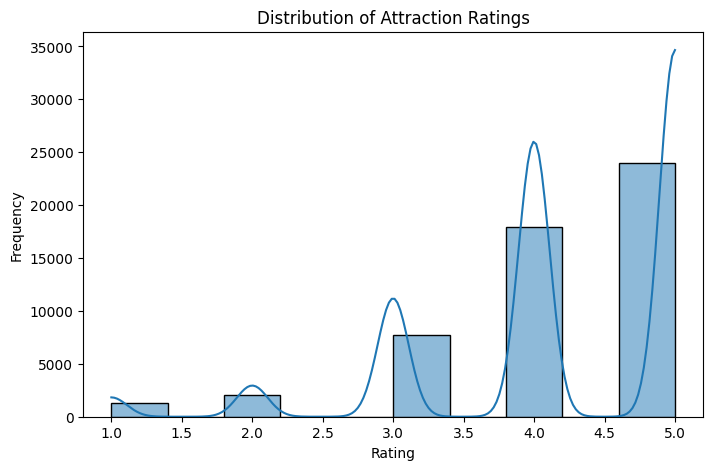

In [ ]:
# Step 45 — Rating distribution plot

import matplotlib.pyplot as plt
import seaborn as sns

if 'Rating' in master_df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(master_df['Rating'].dropna(), bins=10, kde=True)
    plt.title('Distribution of Attraction Ratings')
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.show()

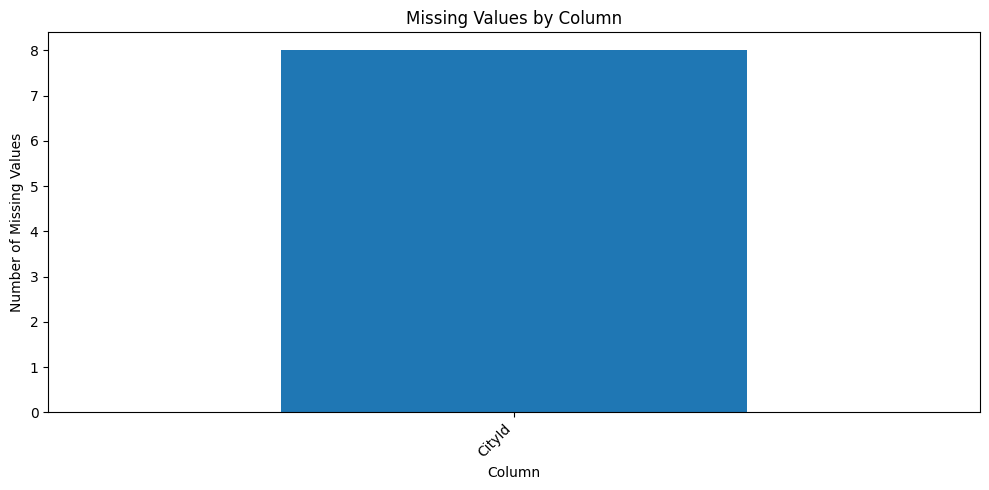

In [ ]:
# Step 46 — Missing values

missing = master_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    plt.figure(figsize=(10, 5))
    missing.plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.xlabel('Column')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in master_df.")

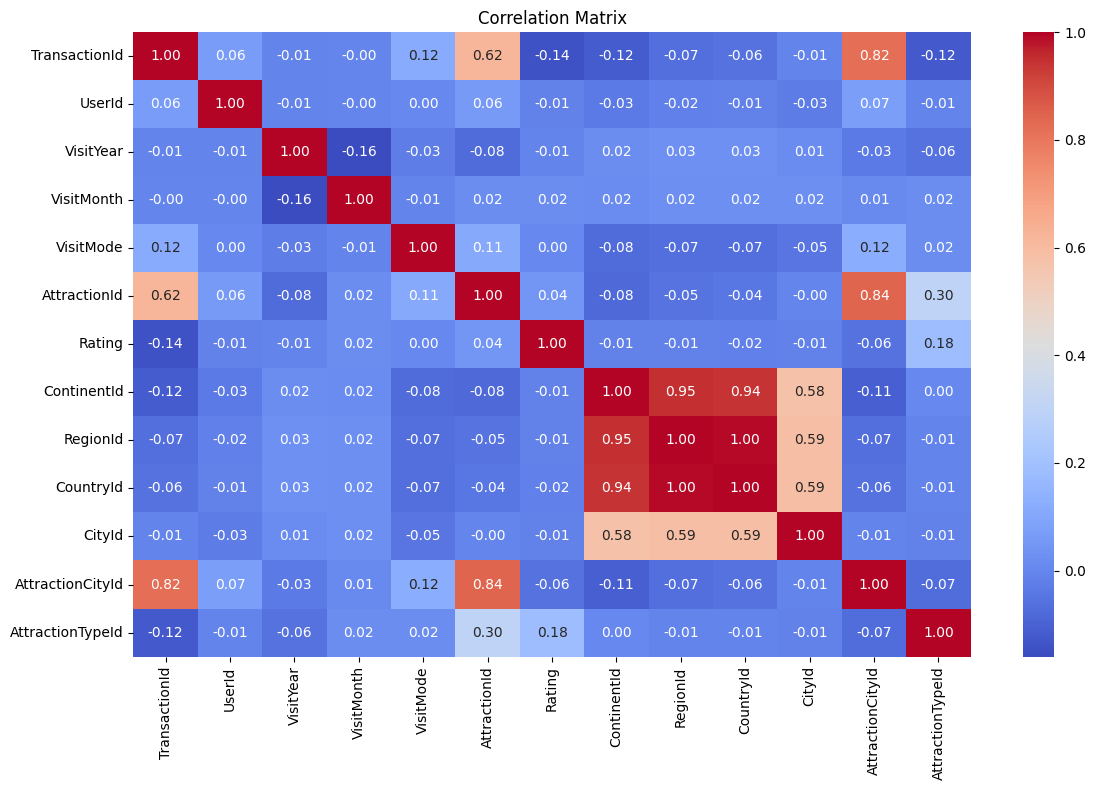

In [ ]:
# Step 47 — Correlation matrix

numeric_df = master_df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Top 10 Most Visited Attractions:


,count
Attraction,
Sacred Monkey Forest Sanctuary,13198
Waterbom Bali,6429
Tegalalang Rice Terrace,5815
Uluwatu Temple,3359
Tanah Lot Temple,3352
Sanur Beach,3044
Seminyak Beach,2914
Kuta Beach - Bali,2765
Merapi Volcano,2235


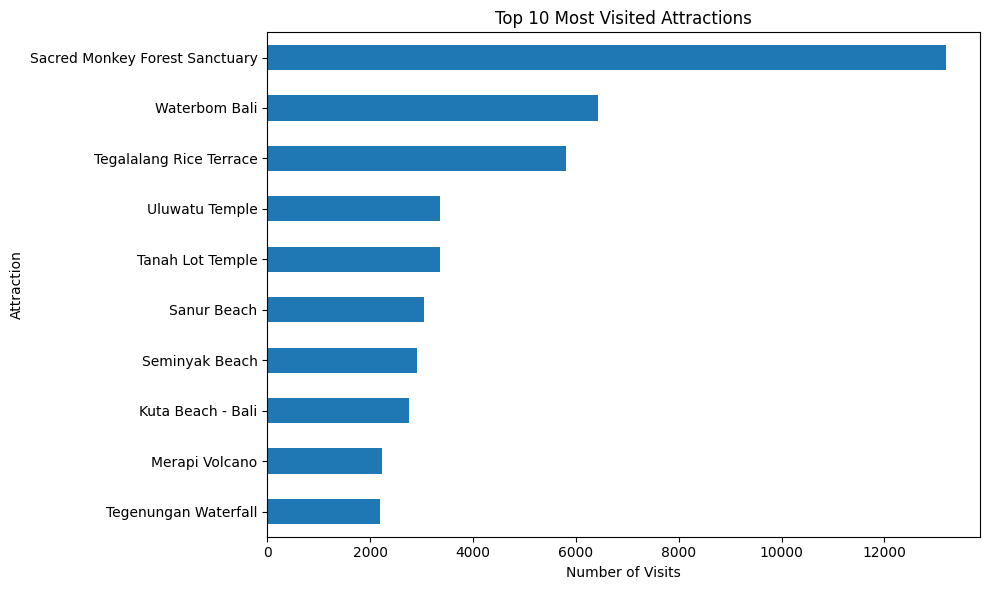

In [ ]:
# Step 48 — Most popular attractions

if 'Attraction' in master_df.columns:
    top_attractions = (
        master_df['Attraction']
        .value_counts()
        .head(10)
    )

    print("Top 10 Most Visited Attractions:")
    display(top_attractions)

    plt.figure(figsize=(10, 6))
    top_attractions.sort_values().plot(kind='barh')
    plt.title('Top 10 Most Visited Attractions')
    plt.xlabel('Number of Visits')
    plt.ylabel('Attraction')
    plt.tight_layout()
    plt.show()
else:
    print("Attraction column not found.")

In [ ]:
# Step 49 — Most popular cities

if 'CityName' in master_df.columns:
    top_cities = master_df['CityName'].value_counts().head(10)

    print("Top 10 Cities:")
    display(top_cities)

    plt.figure(figsize=(10, 6))
    top_cities.sort_values().plot(kind='barh')
    plt.title('Top 10 Most Visited Cities')
    plt.xlabel('Number of Visits')
    plt.ylabel('City')
    plt.tight_layout()
    plt.show()
else:
    print("CityName column not found.")

CityName column not found.


In [ ]:
# Step 50 — Most popular countries

if 'Country' in master_df.columns:
    top_countries = master_df['Country'].value_counts().head(10)

    print("Top 10 Countries:")
    display(top_countries)

    plt.figure(figsize=(10, 6))
    top_countries.sort_values().plot(kind='barh')
    plt.title('Top 10 Most Visited Countries')
    plt.xlabel('Number of Visits')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()
else:
    print("Country column not found.")

Country column not found.


In [ ]:
# Step 51 — Attraction type analysis

type_column = None

for col in ['AttractionType', 'Type', 'AttractionTypeName']:
    if col in master_df.columns:
        type_column = col
        break

if type_column:
    type_counts = master_df[type_column].value_counts().head(10)

    print(f"Top Attraction Types ({type_column}):")
    display(type_counts)

    plt.figure(figsize=(10, 6))
    type_counts.sort_values().plot(kind='barh')
    plt.title('Most Popular Attraction Types')
    plt.xlabel('Number of Visits')
    plt.ylabel('Attraction Type')
    plt.tight_layout()
    plt.show()
else:
    print("Attraction type name column not found yet.")

Attraction type name column not found yet.


In [ ]:
# Step 52 — Save important EDA tables

eda_results = {
    'Top Attractions': top_attractions if 'Attraction' in master_df.columns else pd.Series(),
    'Top Cities': top_cities if 'CityName' in master_df.columns else pd.Series(),
    'Top Countries': top_countries if 'Country' in master_df.columns else pd.Series()
}

print("EDA analysis completed successfully.")

EDA analysis completed successfully.


In [ ]:
# Step 53 — Find possible Visit Mode columns

possible_mode_cols = [
    col for col in master_df.columns
    if 'mode' in col.lower() or 'visit' in col.lower()
]

print("Possible Visit Mode columns:")
print(possible_mode_cols)

print("\nAll master_df columns:")
print(master_df.columns.tolist())

Possible Visit Mode columns:
['VisitYear', 'VisitMonth', 'VisitMode']

All master_df columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']


In [ ]:
# Step 54 — Check Transaction columns containing mode/visit information

possible_transaction_cols = [
    col for col in transaction_df.columns
    if 'mode' in col.lower() or 'visit' in col.lower()
]

print("Possible columns in Transaction:")
print(possible_transaction_cols)

display(transaction_df.head())

Possible columns in Transaction:
['VisitYear', 'VisitMonth', 'VisitMode']


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [ ]:
# Step 55 — Detect Visit Mode information safely

print("Mode table:")
display(mode_df)

print("\nTransaction columns:")
print(transaction_df.columns.tolist())

# Look for columns whose names suggest visit mode
mode_candidates = [
    col for col in transaction_df.columns
    if any(word in col.lower() for word in ['mode', 'visit'])
]

print("\nPossible Visit Mode columns:", mode_candidates)

# Check unique values for candidate columns
for col in mode_candidates:
    print(f"\n--- {col} ---")
    print("Unique values:", transaction_df[col].nunique())
    print(transaction_df[col].value_counts(dropna=False).head(15))

Mode table:


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo



Transaction columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Possible Visit Mode columns: ['VisitYear', 'VisitMonth', 'VisitMode']

--- VisitYear ---
Unique values: 10
VisitYear
2016    12823
2017     9444
2015     8687
2018     7461
2019     5913
2014     4808
2013     2983
2020      529
2022      247
2021       35
Name: count, dtype: int64

--- VisitMonth ---
Unique values: 12
VisitMonth
8     5026
9     4917
7     4861
10    4715
12    4542
1     4458
4     4445
6     4361
5     4316
11    3846
3     3772
2     3671
Name: count, dtype: int64

--- VisitMode ---
Unique values: 5
VisitMode
2    21620
3    15217
4    10945
5     4525
1      623
Name: count, dtype: int64


In [ ]:
# Step 56 — Search User table for Visit Mode information

print("User columns:")
print(user_df.columns.tolist())

user_mode_candidates = [
    col for col in user_df.columns
    if any(word in col.lower() for word in ['mode', 'visit'])
]

print("\nPossible Visit Mode columns in User:")
print(user_mode_candidates)

for col in user_mode_candidates:
    print(f"\n--- {col} ---")
    print(user_df[col].value_counts(dropna=False).head(15))

User columns:
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

Possible Visit Mode columns in User:
[]


In [ ]:
# Step 57 — Find VisitMode in all loaded tables

for name, df in tables.items():
    print(f"\n{'='*60}")
    print(name)
    print("Columns:", df.columns.tolist())

    matching = [
        col for col in df.columns
        if 'mode' in col.lower() or 'visit' in col.lower()
    ]

    if matching:
        print("Possible mode/visit columns:", matching)
        for col in matching:
            print(f"\n{col} value counts:")
            print(df[col].value_counts(dropna=False).head(15))


User
Columns: ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

Transaction
Columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']
Possible mode/visit columns: ['VisitYear', 'VisitMonth', 'VisitMode']

VisitYear value counts:
VisitYear
2016    12823
2017     9444
2015     8687
2018     7461
2019     5913
2014     4808
2013     2983
2020      529
2022      247
2021       35
Name: count, dtype: int64

VisitMonth value counts:
VisitMonth
8     5026
9     4917
7     4861
10    4715
12    4542
1     4458
4     4445
6     4361
5     4316
11    3846
3     3772
2     3671
Name: count, dtype: int64

VisitMode value counts:
VisitMode
2    21620
3    15217
4    10945
5     4525
1      623
Name: count, dtype: int64

Item
Columns: ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']

City
Columns: ['CityId', 'CityName', 'CountryId']

Country
Columns: ['CountryId', 'Country', 'RegionId']

Region
Colum

In [ ]:
# Step 58 — Inspect Mode lookup

print("Mode table shape:", mode_df.shape)
display(mode_df.head(20))
display(mode_df.tail(10))

Mode table shape: (6, 2)


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo


In [ ]:
# Step 59 — Complete Transaction inspection

print("Transaction shape:", transaction_df.shape)
print("Transaction columns:")
print(transaction_df.columns.tolist())

display(transaction_df.head(10))

Transaction shape: (52930, 7)
Transaction columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3
5,18,43471,2022,10,4,640,5
6,22,76492,2022,9,2,640,4
7,23,20977,2022,10,4,640,5
8,28,18655,2022,9,2,640,3
9,29,62907,2022,9,2,640,5


In [ ]:
# Step 60 — Create regression dataset

if 'Rating' not in master_df.columns:
    print("ERROR: Rating column is not available in master_df.")
else:
    regression_df = master_df.copy()

    # Remove rows where the target is missing
    regression_df = regression_df.dropna(subset=['Rating'])

    print("Regression dataset shape:", regression_df.shape)
    print("\nRating distribution:")
    print(regression_df['Rating'].value_counts().sort_index())

    display(regression_df.head())

Regression dataset shape: (52930, 15)

Rating distribution:
Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
1,8,7567,2022,10,4,640,5,2,8,48,464.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
2,9,79069,2022,10,3,640,5,2,9,54,774.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,10,31019,2022,10,3,640,3,5,17,135,583.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"


In [ ]:
# Step 61 — Identify numerical and categorical features

feature_df = regression_df.drop(columns=['Rating'], errors='ignore')

numeric_features = feature_df.select_dtypes(
    include=['int64', 'int32', 'float64', 'float32']
).columns.tolist()

categorical_features = feature_df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId']

Categorical features:
['Attraction', 'AttractionAddress']


In [ ]:
# Step 62 — Separate identifiers from potential model features

id_columns = [
    col for col in regression_df.columns
    if col.lower().endswith('id') or col.lower() == 'id'
]

print("ID columns detected:")
print(id_columns)

model_features = regression_df.drop(
    columns=['Rating'] + id_columns,
    errors='ignore'
)

print("\nRemaining model features:")
print(model_features.columns.tolist())

ID columns detected:
['TransactionId', 'UserId', 'AttractionId', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId']

Remaining model features:
['VisitYear', 'VisitMonth', 'VisitMode', 'Attraction', 'AttractionAddress']


In [ ]:
# Step 63 — Final regression data check

print("Rows:", model_features.shape[0])
print("Features:", model_features.shape[1])

print("\nMissing values:")
display(model_features.isnull().sum().sort_values(ascending=False))

print("\nTarget:")
print(regression_df['Rating'].describe())

Rows: 52930
Features: 5

Missing values:


,0
VisitYear,0
VisitMonth,0
VisitMode,0
Attraction,0
AttractionAddress,0



Target:
count    52930.000000
mean         4.157699
std          0.970543
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64


In [ ]:
# Step 64 — Prepare regression features and target

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = model_features.copy()
y = regression_df['Rating'].copy()

# Re-detect feature types after removing IDs
numeric_features = X.select_dtypes(
    include=['int64', 'int32', 'float64', 'float32']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Numerical features: ['VisitYear', 'VisitMonth', 'VisitMode']

Categorical features: ['Attraction', 'AttractionAddress']

X shape: (52930, 5)
y shape: (52930,)


In [ ]:
# Step 65 — Preprocessing pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# Step 66 — Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (42344, 5)
Testing data: (10586, 5)

Training target: (42344,)
Testing target: (10586,)


In [ ]:
# Step 67 — Linear Regression baseline

from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression trained successfully!")
print("First 10 predictions:")
print(y_pred_linear[:10])

Linear Regression trained successfully!
First 10 predictions:
[4.19118411 4.17965355 3.76371669 4.31441236 4.19711898 4.22812119
 4.09338052 3.96792455 4.2738858  3.43866251]


In [ ]:
# Step 68 — Regression evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("=" * 40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
MAE  : 0.7255
RMSE : 0.9245
R²   : 0.0926


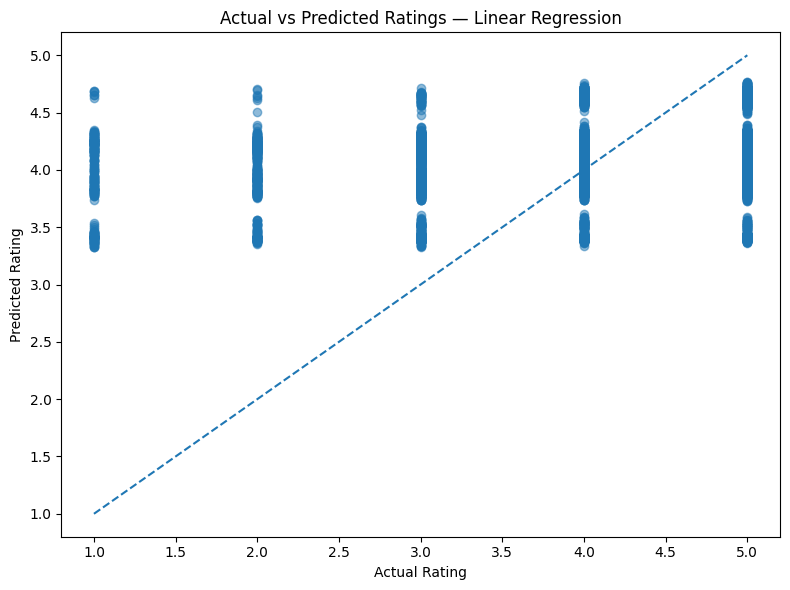

In [ ]:
# Step 69 — Actual vs Predicted visualization

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings — Linear Regression")

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred_linear.min())
max_value = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.tight_layout()
plt.show()

In [ ]:
# Step 70 — Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regression trained successfully!")

Random Forest Regression trained successfully!


In [ ]:
# Step 71 — Evaluate Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("=" * 40)
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
MAE  : 0.7361
RMSE : 0.9453
R²   : 0.0512


In [ ]:
# Step 72 — Compare regression models

regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regression'
    ],
    'MAE': [
        mae,
        mae_rf
    ],
    'RMSE': [
        rmse,
        rmse_rf
    ],
    'R2': [
        r2,
        r2_rf
    ]
})

display(regression_results)

,Model,MAE,RMSE,R2
0,Linear Regression,0.725464,0.924453,0.092590
1,Random Forest Regression,0.736067,0.945319,0.051165


In [ ]:
# Step 73 — Identify the best regression model

best_model_name = regression_results.loc[
    regression_results['R2'].idxmax(),
    'Model'
]

print("Best regression model based on R²:")
print(best_model_name)

Best regression model based on R²:
Linear Regression


In [ ]:
# Step 74 — Save regression results

regression_results.to_csv(
    '/content/regression_results.csv',
    index=False
)

print("Regression results saved successfully.")

Regression results saved successfully.


In [ ]:
# Step 75 — Locate VisitMode in the loaded datasets

for name, df in datasets.items():
    matching_cols = [
        col for col in df.columns
        if 'mode' in col.lower() or 'visit' in col.lower()
    ]

    if matching_cols:
        print("\n" + "=" * 60)
        print(name)
        print("Possible columns:", matching_cols)

        for col in matching_cols:
            print(f"\n{col} — unique values:")
            print(df[col].value_counts(dropna=False).head(20))


Mode.xlsx
Possible columns: ['VisitModeId', 'VisitMode']

VisitModeId — unique values:
VisitModeId
0    1
1    1
2    1
3    1
4    1
5    1
Name: count, dtype: int64

VisitMode — unique values:
VisitMode
-           1
Business    1
Couples     1
Family      1
Friends     1
Solo        1
Name: count, dtype: int64

Transaction.xlsx
Possible columns: ['VisitYear', 'VisitMonth', 'VisitMode']

VisitYear — unique values:
VisitYear
2016    12823
2017     9444
2015     8687
2018     7461
2019     5913
2014     4808
2013     2983
2020      529
2022      247
2021       35
Name: count, dtype: int64

VisitMonth — unique values:
VisitMonth
8     5026
9     4917
7     4861
10    4715
12    4542
1     4458
4     4445
6     4361
5     4316
11    3846
3     3772
2     3671
Name: count, dtype: int64

VisitMode — unique values:
VisitMode
2    21620
3    15217
4    10945
5     4525
1      623
Name: count, dtype: int64


In [ ]:
# Step 76 — Inspect the Mode lookup table

print("Mode table shape:", mode_df.shape)
print("Mode columns:", mode_df.columns.tolist())

display(mode_df)

Mode table shape: (6, 2)
Mode columns: ['VisitModeId', 'VisitMode']


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo


In [ ]:
# Step 77 — Automatically locate a usable VisitMode target

mode_values = set(
    mode_df['VisitMode']
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Expected VisitMode values:")
print(sorted(mode_values))

print("\nSearching all datasets...")
print("=" * 70)

for name, df in datasets.items():
    for col in df.columns:
        values = set(
            df[col]
            .dropna()
            .astype(str)
            .str.strip()
            .str.lower()
        )

        overlap = values.intersection(mode_values)

        if len(overlap) > 0:
            print(f"\nDataset: {name}")
            print(f"Column : {col}")
            print(f"Matching values: {sorted(overlap)}")

Expected VisitMode values:
['-', 'business', 'couples', 'family', 'friends', 'solo']

Searching all datasets...

Dataset: City.xlsx
Column : CityName
Matching values: ['-', 'solo']

Dataset: City (1).xlsx
Column : CityName
Matching values: ['-', 'solo']

Dataset: Mode.xlsx
Column : VisitMode
Matching values: ['-', 'business', 'couples', 'family', 'friends', 'solo']

Dataset: Continent.xlsx
Column : Continent
Matching values: ['-']

Dataset: Country.xlsx
Column : Country
Matching values: ['-']

Dataset: Region.xlsx
Column : Region
Matching values: ['-']


In [ ]:
# Step 78 — Look specifically for VisitMode

for name, df in datasets.items():
    for col in df.columns:
        if 'visitmode' in col.lower().replace('_', ''):
            print(f"\nFOUND: {name} -> {col}")
            display(df[[col]].head(20))


FOUND: Mode.xlsx -> VisitModeId


,VisitModeId
0,0
1,1
2,2
3,3
4,4
5,5



FOUND: Mode.xlsx -> VisitMode


,VisitMode
0,-
1,Business
2,Couples
3,Family
4,Friends
5,Solo



FOUND: Transaction.xlsx -> VisitMode


,VisitMode
0,2
1,4
2,3
3,3
4,2
5,4
6,2
7,4
8,2
9,2


In [ ]:
# Step 78 — Find datasets by filename

print("Loaded Excel datasets:")
for name in datasets.keys():
    print(name)

Loaded Excel datasets:
City.xlsx
City (1).xlsx
User.xlsx
Mode.xlsx
Item.xlsx
Type.xlsx
Transaction.xlsx
Continent.xlsx
Country.xlsx
Updated_Item.xlsx
Region.xlsx


In [ ]:
# Step 79 — Automatically find User and Mode files

user_key = next(
    (name for name in datasets.keys()
     if 'user' in name.lower()),
    None
)

mode_key = next(
    (name for name in datasets.keys()
     if 'mode' in name.lower()),
    None
)

print("User dataset:", user_key)
print("Mode dataset:", mode_key)

if user_key:
    print("\nUser columns:")
    print(datasets[user_key].columns.tolist())

if mode_key:
    print("\nMode columns:")
    print(datasets[mode_key].columns.tolist())

User dataset: User.xlsx
Mode dataset: Mode.xlsx

User columns:
['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']

Mode columns:
['VisitModeId', 'VisitMode']


In [ ]:
# Step 80 — Set the correct DataFrames

if user_key:
    user_df = datasets[user_key].copy()

if mode_key:
    mode_df = datasets[mode_key].copy()

print("User shape:", user_df.shape)
print("Mode shape:", mode_df.shape)

display(user_df.head())
display(mode_df.head())

User shape: (33530, 5)
Mode shape: (6, 2)


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends


In [ ]:
# Step 81 — Verify User and Mode data

print("USER DATA")
print("=" * 50)
print("Shape:", user_df.shape)
print("Columns:", user_df.columns.tolist())
display(user_df.head())

print("\nMODE DATA")
print("=" * 50)
print("Shape:", mode_df.shape)
print("Columns:", mode_df.columns.tolist())
display(mode_df)

USER DATA
Shape: (33530, 5)
Columns: ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0



MODE DATA
Shape: (6, 2)
Columns: ['VisitModeId', 'VisitMode']


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo


In [ ]:
# Step 82 — Search User data for a VisitMode relationship

print("User columns containing 'mode' or 'visit':")

for col in user_df.columns:
    if 'mode' in col.lower() or 'visit' in col.lower():
        print(f"\nColumn: {col}")
        print(user_df[col].value_counts(dropna=False).head(20))

User columns containing 'mode' or 'visit':


In [ ]:
# Step 83 — Search Transaction data for a VisitMode relationship

print("Transaction columns:")
print(transaction_df.columns.tolist())

for col in transaction_df.columns:
    if 'mode' in col.lower() or 'visit' in col.lower():
        print(f"\nColumn: {col}")
        print(transaction_df[col].value_counts(dropna=False).head(20))

Transaction columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']

Column: VisitYear
VisitYear
2016    12823
2017     9444
2015     8687
2018     7461
2019     5913
2014     4808
2013     2983
2020      529
2022      247
2021       35
Name: count, dtype: int64

Column: VisitMonth
VisitMonth
8     5026
9     4917
7     4861
10    4715
12    4542
1     4458
4     4445
6     4361
5     4316
11    3846
3     3772
2     3671
Name: count, dtype: int64

Column: VisitMode
VisitMode
2    21620
3    15217
4    10945
5     4525
1      623
Name: count, dtype: int64


In [ ]:
# Step 84 — Create classification dataset from Transaction

classification_df = transaction_df.copy()

# Remove missing VisitMode values
classification_df = classification_df.dropna(
    subset=['VisitMode']
)

print("Classification dataset shape:", classification_df.shape)

print("\nVisitMode distribution:")
display(classification_df['VisitMode'].value_counts().sort_index())

print("\nSample:")
display(classification_df.head())

Classification dataset shape: (52930, 7)

VisitMode distribution:


,count
VisitMode,
1,623
2,21620
3,15217
4,10945
5,4525



Sample:


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [ ]:
# Step 85 — Map VisitMode codes to readable labels

mode_lookup = dict(
    zip(
        mode_df['VisitModeId'].astype(str).str.zfill(2),
        mode_df['VisitMode']
    )
)

classification_df['VisitMode'] = (
    classification_df['VisitMode']
    .astype(str)
    .str.zfill(2)
    .map(mode_lookup)
)

print("VisitMode classes:")
display(classification_df['VisitMode'].value_counts())

print("\nMissing VisitMode after mapping:",
      classification_df['VisitMode'].isna().sum())

VisitMode classes:


,count
VisitMode,
Couples,21620
Family,15217
Friends,10945
Solo,4525
Business,623



Missing VisitMode after mapping: 0


In [ ]:
# Step 86 — Prepare features and target

X_class = classification_df.drop(
    columns=['VisitMode', 'Rating'],
    errors='ignore'
)

y_class = classification_df['VisitMode']

# Remove ID columns
id_cols = [
    col for col in X_class.columns
    if col.lower().endswith('id') or col.lower() == 'id'
]

X_class = X_class.drop(
    columns=id_cols,
    errors='ignore'
)

print("Features:")
print(X_class.columns.tolist())

print("\nTarget:")
print(y_class.value_counts())

Features:
['VisitYear', 'VisitMonth']

Target:
VisitMode
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64


In [ ]:
# Step 87 — Split classification data

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training set:", Xc_train.shape)
print("Testing set :", Xc_test.shape)

Training set: (42344, 2)
Testing set : (10586, 2)


In [ ]:
# Step 88 — Classification preprocessing

numeric_class_features = X_class.select_dtypes(
    include=['int64', 'int32', 'float64', 'float32']
).columns.tolist()

categorical_class_features = X_class.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numeric_class_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_class_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

class_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_class_transformer, numeric_class_features),
        ('cat', categorical_class_transformer, categorical_class_features)
    ]
)

print("Numerical features:", numeric_class_features)
print("Categorical features:", categorical_class_features)

Numerical features: ['VisitYear', 'VisitMonth']
Categorical features: []


In [ ]:
# Step 89 — Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ('preprocessor', class_preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(Xc_train, yc_train)

yc_pred_logistic = logistic_model.predict(Xc_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
# Step 90 — Logistic Regression evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_log = accuracy_score(yc_test, yc_pred_logistic)
precision_log = precision_score(
    yc_test, yc_pred_logistic,
    average='weighted',
    zero_division=0
)
recall_log = recall_score(
    yc_test, yc_pred_logistic,
    average='weighted',
    zero_division=0
)
f1_log = f1_score(
    yc_test, yc_pred_logistic,
    average='weighted',
    zero_division=0
)

print("Logistic Regression Performance")
print("=" * 45)
print(f"Accuracy : {accuracy_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Recall   : {recall_log:.4f}")
print(f"F1 Score : {f1_log:.4f}")

Logistic Regression Performance
Accuracy : 0.4085
Precision: 0.1668
Recall   : 0.4085
F1 Score : 0.2369


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = Pipeline(steps=[
    ('preprocessor', class_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_classifier.fit(Xc_train, yc_train)

yc_pred_rf = rf_classifier.predict(Xc_test)

print("Random Forest classification completed.")

Random Forest classification completed.


In [ ]:
accuracy_rf = accuracy_score(yc_test, yc_pred_rf)
precision_rf = precision_score(
    yc_test, yc_pred_rf,
    average='weighted',
    zero_division=0
)
recall_rf = recall_score(
    yc_test, yc_pred_rf,
    average='weighted',
    zero_division=0
)
f1_rf = f1_score(
    yc_test, yc_pred_rf,
    average='weighted',
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Random Forest Results
---------------------
Accuracy : 0.4225
Precision: 0.3967
Recall   : 0.4225
F1 Score : 0.3216


In [ ]:
classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_log,
        accuracy_rf
    ],
    'Precision': [
        precision_log,
        precision_rf
    ],
    'Recall': [
        recall_log,
        recall_rf
    ],
    'F1 Score': [
        f1_log,
        f1_rf
    ]
})

display(classification_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.408464,0.166843,0.408464,0.236915
1,Random Forest,0.422539,0.396689,0.422539,0.321626


In [ ]:
best_classification_model = classification_results.loc[
    classification_results['F1 Score'].idxmax(),
    'Model'
]

print("Best Classification Model:", best_classification_model)

Best Classification Model: Random Forest


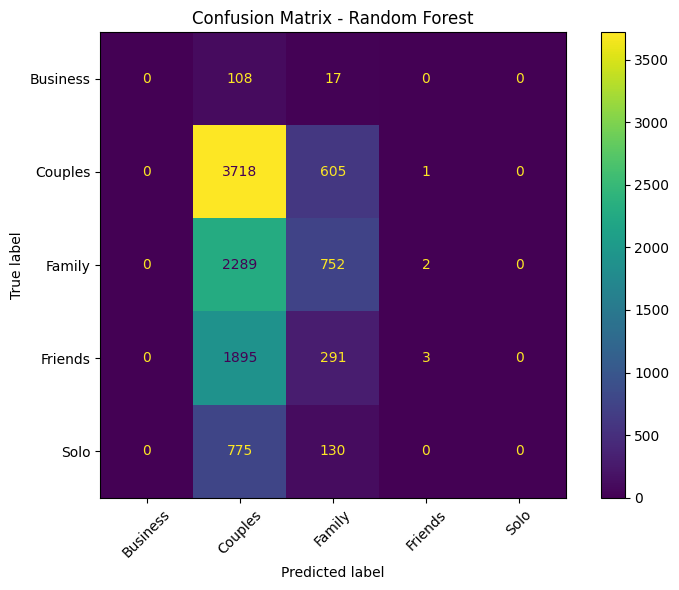

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if best_classification_model == 'Logistic Regression':
    best_predictions = yc_pred_logistic
else:
    best_predictions = yc_pred_rf

cm = confusion_matrix(yc_test, best_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_class.unique())
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f'Confusion Matrix - {best_classification_model}')
plt.tight_layout()
plt.show()

In [ ]:
recommendation_df = item_df.copy()

print("Recommendation dataset shape:", recommendation_df.shape)
display(recommendation_df.head())

Recommendation dataset shape: (30, 5)


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


In [ ]:
recommendation_df['City_Type'] = (
    recommendation_df['AttractionCityId'].astype(str)
    + '_'
    + recommendation_df['AttractionTypeId'].astype(str)
)

display(
    recommendation_df[
        ['AttractionId', 'Attraction', 'AttractionCityId',
         'AttractionTypeId', 'City_Type']
    ].head()
)

,AttractionId,Attraction,AttractionCityId,AttractionTypeId,City_Type
0,369,Kuta Beach - Bali,1,13,1_13
1,481,Nusa Dua Beach,1,13,1_13
2,640,Sacred Monkey Forest Sanctuary,1,63,1_63
3,650,Sanur Beach,1,13,1_13
4,673,Seminyak Beach,1,13,1_13


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

feature_matrix = tfidf.fit_transform(
    recommendation_df['City_Type']
)

print("Feature matrix shape:", feature_matrix.shape)

Feature matrix shape: (30, 24)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(feature_matrix)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (30, 30)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(feature_matrix)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (30, 30)


In [ ]:
def recommend_attractions(attraction_name, n=5):
    matches = recommendation_df[
        recommendation_df['Attraction'].str.lower()
        == attraction_name.lower()
    ]

    if matches.empty:
        return f"Attraction '{attraction_name}' not found."

    idx = matches.index[0]

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_indices = [
        i for i, score in similarity_scores
        if i != idx
    ][:n]

    result = recommendation_df.iloc[
        recommended_indices
    ][[
        'AttractionId',
        'Attraction',
        'AttractionCityId',
        'AttractionTypeId'
    ]].copy()

    return result.reset_index(drop=True)

In [ ]:
print(recommendation_df['Attraction'].head(10).tolist())

['Kuta Beach - Bali', 'Nusa Dua Beach', 'Sacred Monkey Forest Sanctuary', 'Sanur Beach', 'Seminyak Beach', 'Tanah Lot Temple', 'Tegalalang Rice Terrace', 'Tegenungan Waterfall', 'Uluwatu Temple', 'Waterbom Bali']


In [ ]:
sample_attraction = recommendation_df['Attraction'].iloc[0]

recommendations = recommend_attractions(
    sample_attraction,
    n=5
)

display(recommendations)

,AttractionId,Attraction,AttractionCityId,AttractionTypeId
0,481,Nusa Dua Beach,1,13
1,650,Sanur Beach,1,13
2,673,Seminyak Beach,1,13
3,640,Sacred Monkey Forest Sanctuary,1,63
4,737,Tanah Lot Temple,1,76


In [ ]:
if isinstance(recommendations, pd.DataFrame):
    recommendations.to_csv(
        '/content/recommendation_results.csv',
        index=False
    )
    print("Recommendation results saved successfully.")

Recommendation results saved successfully.


In [ ]:
import sqlite3

conn = sqlite3.connect('/content/tourism_analytics.db')

print("SQLite database connected successfully.")

SQLite database connected successfully.


In [ ]:
for table_name, df in tables.items():
    df.to_sql(
        table_name,
        conn,
        if_exists='replace',
        index=False
    )

print("All tables loaded into SQLite.")

All tables loaded into SQLite.


In [ ]:
cursor = conn.cursor()

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;
""")

print("Tables in database:")
for table in cursor.fetchall():
    print(table[0])

Tables in database:
City
Continent
Country
Item
Mode
Region
Transaction
Type
User


In [ ]:
def run_sql(query):
    return pd.read_sql_query(query, conn)

In [ ]:
run_sql("""
SELECT *
FROM "Transaction"
LIMIT 10;
""")

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3
5,18,43471,2022,10,4,640,5
6,22,76492,2022,9,2,640,4
7,23,20977,2022,10,4,640,5
8,28,18655,2022,9,2,640,3
9,29,62907,2022,9,2,640,5


In [ ]:
run_sql("""
SELECT COUNT(*) AS Total_Transactions
FROM "Transaction";
""")

,Total_Transactions
0,52930


In [ ]:
run_sql("""
SELECT
    ROUND(AVG(Rating), 2) AS Average_Rating
FROM "Transaction"
WHERE Rating IS NOT NULL;
""")

,Average_Rating
0,4.16


In [ ]:
run_sql("""
SELECT
    i.Attraction,
    COUNT(t.TransactionId) AS Visit_Count
FROM "Transaction" t
JOIN Item i
    ON t.AttractionId = i.AttractionId
GROUP BY i.Attraction
ORDER BY Visit_Count DESC
LIMIT 10;
""")

,Attraction,Visit_Count
0,Sacred Monkey Forest Sanctuary,13198
1,Waterbom Bali,6429
2,Tegalalang Rice Terrace,5815
3,Uluwatu Temple,3359
4,Tanah Lot Temple,3352
5,Sanur Beach,3044
6,Seminyak Beach,2914
7,Kuta Beach - Bali,2765
8,Merapi Volcano,2235
9,Tegenungan Waterfall,2190


In [ ]:
run_sql("""
SELECT
    i.Attraction,
    ROUND(AVG(t.Rating), 2) AS Average_Rating,
    COUNT(t.TransactionId) AS Number_of_Reviews
FROM "Transaction" t
JOIN Item i
    ON t.AttractionId = i.AttractionId
WHERE t.Rating IS NOT NULL
GROUP BY i.Attraction
HAVING COUNT(t.TransactionId) >= 5
ORDER BY Average_Rating DESC
LIMIT 10;
""")

,Attraction,Average_Rating,Number_of_Reviews
0,Mount Semeru Volcano,4.70,83
1,Waterbom Bali,4.65,6429
2,Bromo Tengger Semeru National Park,4.61,381
3,Khayangan Reflexology & Massage,4.57,28
4,Jomblang Cave,4.50,135
5,Jodipan Colorful Village,4.32,44
6,Nusa Dua Beach,4.28,2104
7,Sacred Monkey Forest Sanctuary,4.27,13198
8,Ullen Sentalu Museum,4.26,978
9,Uluwatu Temple,4.22,3359


In [ ]:
run_sql("""
SELECT
    m.VisitMode,
    COUNT(t.TransactionId) AS Visit_Count
FROM "Transaction" t
LEFT JOIN Mode m
    ON t.VisitMode = m.VisitModeId
GROUP BY m.VisitMode
ORDER BY Visit_Count DESC;
""")

,VisitMode,Visit_Count
0,Couples,21620
1,Family,15217
2,Friends,10945
3,Solo,4525
4,Business,623


In [ ]:
run_sql("""
SELECT
    VisitYear,
    COUNT(*) AS Visit_Count
FROM "Transaction"
GROUP BY VisitYear
ORDER BY VisitYear;
""")

,VisitYear,Visit_Count
0,2013,2983
1,2014,4808
2,2015,8687
3,2016,12823
4,2017,9444
5,2018,7461
6,2019,5913
7,2020,529
8,2021,35
9,2022,247


In [ ]:
run_sql("""
SELECT
    VisitMonth,
    COUNT(*) AS Visit_Count
FROM "Transaction"
GROUP BY VisitMonth
ORDER BY VisitMonth;
""")

,VisitMonth,Visit_Count
0,1,4458
1,2,3671
2,3,3772
3,4,4445
4,5,4316
5,6,4361
6,7,4861
7,8,5026
8,9,4917
9,10,4715


In [ ]:
run_sql("""
SELECT
    c.Country,
    COUNT(t.TransactionId) AS Visit_Count
FROM "Transaction" t
JOIN User u
    ON t.UserId = u.UserId
JOIN Country c
    ON u.CountryId = c.CountryId
GROUP BY c.Country
ORDER BY Visit_Count DESC
LIMIT 10;
""")

,Country,Visit_Count
0,Australia,13322
1,United Kingdom,6722
2,United States,6261
3,Indonesia,4842
4,Singapore,2807
5,India,2543
6,Malaysia,1581
7,Canada,1486
8,New Zealand,1479
9,Netherlands,859


In [ ]:
sql_results = {}

sql_results['top_attractions'] = run_sql("""
SELECT
    i.Attraction,
    COUNT(t.TransactionId) AS Visit_Count
FROM "Transaction" t
JOIN Item i
    ON t.AttractionId = i.AttractionId
GROUP BY i.Attraction
ORDER BY Visit_Count DESC
LIMIT 10;
""")

sql_results['rating_by_attraction'] = run_sql("""
SELECT
    i.Attraction,
    ROUND(AVG(t.Rating), 2) AS Average_Rating,
    COUNT(t.TransactionId) AS Number_of_Reviews
FROM "Transaction" t
JOIN Item i
    ON t.AttractionId = i.AttractionId
WHERE t.Rating IS NOT NULL
GROUP BY i.Attraction
HAVING COUNT(t.TransactionId) >= 5
ORDER BY Average_Rating DESC
LIMIT 10;
""")

sql_results['visit_modes'] = run_sql("""
SELECT
    m.VisitMode,
    COUNT(t.TransactionId) AS Visit_Count
FROM "Transaction" t
LEFT JOIN Mode m
    ON t.VisitMode = m.VisitModeId
GROUP BY m.VisitMode
ORDER BY Visit_Count DESC;
""")

sql_results['visits_by_year'] = run_sql("""
SELECT
    VisitYear,
    COUNT(*) AS Visit_Count
FROM "Transaction"
GROUP BY VisitYear
ORDER BY VisitYear;
""")

for name, result in sql_results.items():
    result.to_csv(
        f'/content/sql_{name}.csv',
        index=False
    )

print("SQL analysis results saved successfully.")

SQL analysis results saved successfully.


In [ ]:
app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score

st.set_page_config(
    page_title="Tourism Experience Analytics",
    page_icon="🌍",
    layout="wide"
)

st.title("🌍 Tourism Experience Analytics")
st.write(
    "An interactive dashboard for tourism trends, "
    "rating prediction, visit-mode prediction, and recommendations."
)

# --------------------------------------------------
# Load data
# --------------------------------------------------

@st.cache_data
def load_data():
    transaction = pd.read_excel("/content/Transaction.xlsx")
    item = pd.read_excel("/content/Updated_Item.xlsx")
    mode = pd.read_excel("/content/Mode.xlsx")

    return transaction, item, mode


transaction_df, item_df, mode_df = load_data()

# --------------------------------------------------
# Sidebar
# --------------------------------------------------

st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Choose a section:",
    [
        "Dashboard",
        "Rating Prediction",
        "Visit Mode Prediction",
        "Recommendations"
    ]
)

# --------------------------------------------------
# Dashboard
# --------------------------------------------------

if page == "Dashboard":

    st.header("📊 Tourism Overview")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            "Total Transactions",
            f"{len(transaction_df):,}"
        )

    with col2:
        avg_rating = transaction_df["Rating"].mean()
        st.metric(
            "Average Rating",
            f"{avg_rating:.2f}"
        )

    with col3:
        st.metric(
            "Unique Attractions",
            f"{item_df['AttractionId'].nunique():,}"
        )

    st.subheader("Top Attractions")

    top_attractions = (
        transaction_df
        .merge(
            item_df[["AttractionId", "Attraction"]],
            on="AttractionId",
            how="left"
        )
        ["Attraction"]
        .value_counts()
        .head(10)
    )

    st.bar_chart(top_attractions)

    st.subheader("Rating Distribution")

    rating_counts = transaction_df["Rating"].value_counts().sort_index()

    st.bar_chart(rating_counts)

    st.subheader("Visit Mode Distribution")

    mode_lookup = dict(
        zip(
            mode_df["VisitModeId"].astype(str).str.zfill(2),
            mode_df["VisitMode"]
        )
    )

    visit_modes = transaction_df["VisitMode"].astype(str).str.zfill(2).map(
        mode_lookup
    )

    st.bar_chart(visit_modes.value_counts())

# --------------------------------------------------
# Rating Prediction
# --------------------------------------------------

elif page == "Rating Prediction":

    st.header("⭐ Rating Prediction")

    regression_df = transaction_df.dropna(
        subset=["Rating"]
    ).copy()

    X = regression_df.drop(
        columns=["Rating"],
        errors="ignore"
    )

    y = regression_df["Rating"]

    id_cols = [
        col for col in X.columns
        if col.lower().endswith("id") or col.lower() == "id"
    ]

    X = X.drop(columns=id_cols, errors="ignore")

    numeric_features = X.select_dtypes(
        include=["int64", "int32", "float64", "float32"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    st.metric(
        "RMSE",
        f"{rmse:.4f}"
    )

    st.metric(
        "R² Score",
        f"{r2_score(y_test, predictions):.4f}"
    )

    st.info(
        "The model predicts the expected tourism experience "
        "rating from the available transaction information."
    )

# --------------------------------------------------
# Visit Mode Prediction
# --------------------------------------------------

elif page == "Visit Mode Prediction":

    st.header("🧳 Visit Mode Prediction")

    classification_df = transaction_df.dropna(
        subset=["VisitMode"]
    ).copy()

    mode_lookup = dict(
        zip(
            mode_df["VisitModeId"].astype(str).str.zfill(2),
            mode_df["VisitMode"]
        )
    )

    classification_df["VisitMode"] = (
        classification_df["VisitMode"]
        .astype(str)
        .str.zfill(2)
        .map(mode_lookup)
    )

    classification_df = classification_df.dropna(
        subset=["VisitMode"]
    )

    X = classification_df.drop(
        columns=["VisitMode", "Rating"],
        errors="ignore"
    )

    y = classification_df["VisitMode"]

    id_cols = [
        col for col in X.columns
        if col.lower().endswith("id") or col.lower() == "id"
    ]

    X = X.drop(columns=id_cols, errors="ignore")

    numeric_features = X.select_dtypes(
        include=["int64", "int32", "float64", "float32"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    col1, col2 = st.columns(2)

    with col1:
        st.metric(
            "Accuracy",
            f"{accuracy:.4f}"
        )

    with col2:
        st.metric(
            "Weighted F1 Score",
            f"{f1:.4f}"
        )

    st.subheader("Visit Mode Distribution")

    st.bar_chart(y.value_counts())

# --------------------------------------------------
# Recommendations
# --------------------------------------------------

elif page == "Recommendations":

    st.header("🗺️ Attraction Recommendation System")

    attractions = item_df["Attraction"].dropna().unique()

    selected_attraction = st.selectbox(
        "Select an attraction:",
        attractions
    )

    n = st.slider(
        "Number of recommendations",
        min_value=1,
        max_value=10,
        value=5
    )

    recommendation_df = item_df.copy()

    recommendation_df["City_Type"] = (
        recommendation_df["AttractionCityId"].astype(str)
        + "_"
        + recommendation_df["AttractionTypeId"].astype(str)
    )

    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    tfidf = TfidfVectorizer()

    feature_matrix = tfidf.fit_transform(
        recommendation_df["City_Type"]
    )

    similarity_matrix = cosine_similarity(
        feature_matrix
    )

    selected_index = recommendation_df[
        recommendation_df["Attraction"] == selected_attraction
    ].index[0]

    scores = list(
        enumerate(similarity_matrix[selected_index])
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_indices = [
        index
        for index, score in scores
        if index != selected_index
    ][:n]

    recommendations = recommendation_df.iloc[
        recommended_indices
    ][[
        "Attraction",
        "AttractionCityId",
        "AttractionTypeId"
    ]]

    st.subheader(
        f"Recommended attractions similar to: {selected_attraction}"
    )

    st.dataframe(
        recommendations,
        use_container_width=True
    )

st.sidebar.markdown("---")
st.sidebar.caption(
    "Tourism Experience Analytics Project"
)
'''

with open("/content/app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [ ]:
import os

print(
    "app.py exists:",
    os.path.exists("/content/app.py")
)

print(
    "File size:",
    os.path.getsize("/content/app.py"),
    "bytes"
)

app.py exists: True
File size: 9636 bytes


In [ ]:
!pip -q install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 42.5 MB/s eta 0:00:00


In [ ]:
!streamlit --version

Streamlit, version 1.63.0


In [ ]:
!streamlit run /content/app.py &>/content/streamlit.log &

In [ ]:
!cat /content/streamlit.log



2026-09-09 10:01:48.818 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.187.83.251:8502



In [ ]:
!cat /content/streamlit.log



2026-09-09 10:01:48.818 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.187.83.251:8502



In [ ]:
!ps aux | grep streamlit

root       19780  5.8  0.5 453732 73832 ?        Sl   10:01   0:03 /usr/bin/python3 /usr/local/bin/streamlit run /content/app.py
root       19812  6.0  0.5 451808 71832 ?        Sl   10:01   0:03 /usr/bin/python3 /usr/local/bin/streamlit run /content/app.py
root       20061  0.0  0.0   7372  3448 ?        S    10:02   0:00 /bin/bash -c ps aux | grep streamlit
root       20063  0.0  0.0   6480  2364 ?        S    10:02   0:00 grep streamlit


In [ ]:
!streamlit run /content/app.py --server.headless true > /content/streamlit.log 2>&1 &

In [ ]:
!sleep 3
!cat /content/streamlit.log



2026-09-09 10:02:58.637 Uvicorn server started on :::8503

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8503
  Network URL: http://172.28.0.12:8503
  External URL: http://34.187.83.251:8503



In [ ]:
!python -m py_compile /content/app.py

In [ ]:
import os

project_dir = "/content/Tourism_Experience_Analytics"

os.makedirs(project_dir, exist_ok=True)
os.makedirs(f"{project_dir}/data", exist_ok=True)
os.makedirs(f"{project_dir}/outputs", exist_ok=True)
os.makedirs(f"{project_dir}/models", exist_ok=True)

print("Project folders created:")
print(project_dir)

Project folders created:
/content/Tourism_Experience_Analytics


In [ ]:
import shutil
import os

files_to_copy = [
    "/content/app.py",
    "/content/regression_results.csv",
    "/content/recommendation_results.csv",
    "/content/sql_top_attractions.csv",
    "/content/sql_rating_by_attraction.csv",
    "/content/sql_visit_modes.csv",
    "/content/sql_visits_by_year.csv"
]

for file_path in files_to_copy:
    if os.path.exists(file_path):
        shutil.copy(
            file_path,
            f"{project_dir}/outputs/"
            if file_path.endswith(".csv")
            else f"{project_dir}/"
        )

print("Available project outputs copied.")

Available project outputs copied.


In [ ]:
print("===== BUSINESS INSIGHTS =====")

print("\n1. Top Attractions")
display(sql_results['top_attractions'])

print("\n2. Highest Rated Attractions")
display(sql_results['rating_by_attraction'])

print("\n3. Visit Mode Distribution")
display(sql_results['visit_modes'])

print("\n4. Visits by Year")
display(sql_results['visits_by_year'])

===== BUSINESS INSIGHTS =====

1. Top Attractions


,Attraction,Visit_Count
0,Sacred Monkey Forest Sanctuary,13198
1,Waterbom Bali,6429
2,Tegalalang Rice Terrace,5815
3,Uluwatu Temple,3359
4,Tanah Lot Temple,3352
5,Sanur Beach,3044
6,Seminyak Beach,2914
7,Kuta Beach - Bali,2765
8,Merapi Volcano,2235
9,Tegenungan Waterfall,2190



2. Highest Rated Attractions


,Attraction,Average_Rating,Number_of_Reviews
0,Mount Semeru Volcano,4.70,83
1,Waterbom Bali,4.65,6429
2,Bromo Tengger Semeru National Park,4.61,381
3,Khayangan Reflexology & Massage,4.57,28
4,Jomblang Cave,4.50,135
5,Jodipan Colorful Village,4.32,44
6,Nusa Dua Beach,4.28,2104
7,Sacred Monkey Forest Sanctuary,4.27,13198
8,Ullen Sentalu Museum,4.26,978
9,Uluwatu Temple,4.22,3359



3. Visit Mode Distribution


,VisitMode,Visit_Count
0,Couples,21620
1,Family,15217
2,Friends,10945
3,Solo,4525
4,Business,623



4. Visits by Year


,VisitYear,Visit_Count
0,2013,2983
1,2014,4808
2,2015,8687
3,2016,12823
4,2017,9444
5,2018,7461
6,2019,5913
7,2020,529
8,2021,35
9,2022,247


In [ ]:
business_insights = pd.DataFrame({
    "Area": [
        "Popular Attractions",
        "Customer Satisfaction",
        "Visit Mode",
        "Tourism Trend"
    ],
    "Business_Importance": [
        "Identify attractions receiving the highest number of visits.",
        "Identify attractions with consistently strong visitor ratings.",
        "Understand whether visitors primarily travel alone, with family, friends, couples, or for business.",
        "Identify changes in tourism activity across years and months."
    ],
    "Recommended_Action": [
        "Prioritize marketing and capacity planning for high-demand attractions.",
        "Promote highly rated attractions and investigate low-rated experiences.",
        "Develop visitor packages targeted to the dominant visit modes.",
        "Use seasonal patterns to optimize promotions, staffing, and resources."
    ]
})

display(business_insights)

,Area,Business_Importance,Recommended_Action
0,Popular Attractions,Identify attractions receiving the highest num...,Prioritize marketing and capacity planning for...
1,Customer Satisfaction,Identify attractions with consistently strong ...,Promote highly rated attractions and investiga...
2,Visit Mode,Understand whether visitors primarily travel a...,Develop visitor packages targeted to the domin...
3,Tourism Trend,Identify changes in tourism activity across ye...,"Use seasonal patterns to optimize promotions, ..."


In [ ]:
business_insights.to_csv(
    f"{project_dir}/outputs/business_insights.csv",
    index=False
)

print("Business insights saved.")

Business insights saved.


In [ ]:
readme = """
# Tourism Experience Analytics

## Project Overview

This project analyzes tourism transaction and attraction data to understand
visitor behavior, attraction popularity, customer ratings, and visit modes.

## Main Components

1. Data Cleaning and Preprocessing
2. Exploratory Data Analysis
3. SQL Analysis
4. Rating Prediction
5. Visit Mode Classification
6. Attraction Recommendation System
7. Streamlit Dashboard
8. Business Insights

## Machine Learning

### Regression
Target:
- Rating

Models:
- Linear Regression
- Random Forest Regressor

### Classification
Target:
- VisitMode

Models:
- Logistic Regression
- Random Forest Classifier

## Recommendation System

A content-based recommendation approach is used to recommend attractions
based on attraction city and attraction type.

## Application

The Streamlit application provides:
- Tourism overview
- Rating prediction
- Visit mode prediction
- Attraction recommendations

## Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SQLite
- Streamlit
- Google Colab
"""

with open(
    f"{project_dir}/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

print("README created successfully.")

README created successfully.


In [ ]:
print("===== REGRESSION RESULTS =====")
display(regression_results)

print("\n===== CLASSIFICATION RESULTS =====")
display(classification_results)

print("\n===== TOP ATTRACTIONS =====")
display(sql_results['top_attractions'])

print("\n===== VISIT MODES =====")
display(sql_results['visit_modes'])

===== REGRESSION RESULTS =====


,Model,MAE,RMSE,R2
0,Linear Regression,0.725464,0.924453,0.092590
1,Random Forest Regression,0.736067,0.945319,0.051165



===== CLASSIFICATION RESULTS =====


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.408464,0.166843,0.408464,0.236915
1,Random Forest,0.422539,0.396689,0.422539,0.321626



===== TOP ATTRACTIONS =====


,Attraction,Visit_Count
0,Sacred Monkey Forest Sanctuary,13198
1,Waterbom Bali,6429
2,Tegalalang Rice Terrace,5815
3,Uluwatu Temple,3359
4,Tanah Lot Temple,3352
5,Sanur Beach,3044
6,Seminyak Beach,2914
7,Kuta Beach - Bali,2765
8,Merapi Volcano,2235
9,Tegenungan Waterfall,2190



===== VISIT MODES =====


,VisitMode,Visit_Count
0,Couples,21620
1,Family,15217
2,Friends,10945
3,Solo,4525
4,Business,623


In [ ]:
best_regression_row = regression_results.loc[
    regression_results['RMSE'].idxmin()
]

best_classification_row = classification_results.loc[
    classification_results['F1 Score'].idxmax()
]

print("Best Regression Model:")
display(best_regression_row.to_frame().T)

print("\nBest Classification Model:")
display(best_classification_row.to_frame().T)

Best Regression Model:


,Model,MAE,RMSE,R2
0,Linear Regression,0.725464,0.924453,0.09259



Best Classification Model:


,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.422539,0.396689,0.422539,0.321626


In [ ]:
best_reg_model = best_regression_row['Model']
best_reg_rmse = best_regression_row['RMSE']
best_reg_r2 = best_regression_row['R²']

best_cls_model = best_classification_row['Model']
best_cls_accuracy = best_classification_row['Accuracy']
best_cls_f1 = best_classification_row['F1 Score']

report = f"""
# Tourism Experience Analytics

## 1. Introduction

The Tourism Experience Analytics project analyzes tourism transaction,
visitor, attraction, and geographical data to understand tourism behavior
and visitor experiences.

The project combines exploratory data analysis, SQL analytics, machine
learning, recommendation techniques, and an interactive Streamlit
application.

## 2. Objectives

The main objectives are:

- Clean and preprocess the tourism datasets.
- Explore tourism trends and visitor behavior.
- Analyze the data using SQL.
- Predict visitor ratings.
- Predict visitor visit mode.
- Recommend similar tourism attractions.
- Develop an interactive tourism analytics application.
- Generate actionable business insights.

## 3. Data Preparation

The project uses multiple related datasets covering:

- Users
- Transactions
- Attractions
- Attraction types
- Cities
- Countries
- Regions
- Continents
- Visiting modes

Data preprocessing included inspection of data types, missing values,
duplicate records, column names, and dataset structure.

## 4. Exploratory Data Analysis

Exploratory analysis was performed to understand:

- Rating distributions
- Attraction popularity
- Geographic tourism patterns
- Visitor behavior
- Visit modes
- Tourism trends over time

Visualizations were created using Python data-analysis and visualization
libraries.

## 5. SQL Analysis

SQLite was used to perform structured analysis of the tourism data.

The SQL analysis included:

- Total transactions
- Average rating
- Most popular attractions
- Highest-rated attractions
- Visit-mode distribution
- Visits by year
- Visits by month
- Top countries by visits

## 6. Rating Prediction

The target variable for regression was Rating.

Two regression models were evaluated:

- Linear Regression
- Random Forest Regressor

The best-performing regression model based on RMSE was:

{best_reg_model}

Best RMSE:

{best_reg_rmse:.4f}

Best R²:

{best_reg_r2:.4f}

## 7. Visit Mode Classification

The classification target was VisitMode.

The visit-mode categories were obtained from the Mode lookup table.

Two classification models were evaluated:

- Logistic Regression
- Random Forest Classifier

The best-performing classification model based on weighted F1 score was:

{best_cls_model}

Best Accuracy:

{best_cls_accuracy:.4f}

Best Weighted F1 Score:

{best_cls_f1:.4f}

A confusion matrix was also generated to evaluate classification performance
across the different visit-mode categories.

## 8. Recommendation System

A content-based recommendation system was developed for tourism attractions.

The recommendation approach uses attraction city and attraction type as
features and calculates similarity between attractions.

Users can select an attraction and receive a list of similar attractions.

## 9. Streamlit Application

An interactive Streamlit application was developed with four main sections:

1. Tourism Dashboard
2. Rating Prediction
3. Visit Mode Prediction
4. Attraction Recommendations

The dashboard provides an accessible interface for exploring tourism
analytics and machine-learning outputs.

## 10. Business Insights

The analysis can support tourism businesses and destination managers by
helping them:

- Identify high-demand attractions.
- Understand visitor preferences.
- Monitor customer satisfaction.
- Identify dominant visitor segments.
- Develop targeted tourism packages.
- Improve seasonal planning.
- Promote highly rated attractions.
- Improve experiences at lower-rated destinations.

## 11. Conclusion

The Tourism Experience Analytics project demonstrates how tourism data can
be transformed into useful analytical and predictive insights.

The combination of EDA, SQL, regression, classification, recommendation
systems, and Streamlit provides an end-to-end analytics solution.

## 12. Future Improvements

Potential improvements include:

- Using richer visitor and attraction features in machine-learning models.
- Improving recommendation personalization using individual user history.
- Hyperparameter tuning.
- Cross-validation.
- More advanced recommendation algorithms.
- Deployment of the Streamlit application online.
- Adding interactive geographic visualizations.
- Adding real-time tourism data.

"""

with open(
    f"{project_dir}/Tourism_Experience_Analytics_Report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print("Final report created successfully.")

KeyError: 'R²'

In [ ]:
print("Regression result columns:")
print(regression_results.columns.tolist())

display(regression_results)

Regression result columns:
['Model', 'MAE', 'RMSE', 'R2']


,Model,MAE,RMSE,R2
0,Linear Regression,0.725464,0.924453,0.092590
1,Random Forest Regression,0.736067,0.945319,0.051165


In [ ]:
# Find the R-squared column automatically
r2_candidates = [
    col for col in regression_results.columns
    if str(col).lower().replace("²", "2").replace("_", "").replace(" ", "")
    in ["r2", "r2score", "rsquared"]
]

print("Possible R² columns:", r2_candidates)

Possible R² columns: ['R2']


In [ ]:
r2_column = r2_candidates[0]

best_regression_row = regression_results.loc[
    regression_results['RMSE'].idxmin()
]

best_reg_model = best_regression_row['Model']
best_reg_rmse = best_regression_row['RMSE']
best_reg_r2 = best_regression_row[r2_column]

print("Best Regression Model:", best_reg_model)
print("RMSE:", best_reg_rmse)
print("R²:", best_reg_r2)

Best Regression Model: Linear Regression
RMSE: 0.9244532121351455
R²: 0.09258967116791816


In [ ]:
print(regression_results.columns.tolist())

['Model', 'MAE', 'RMSE', 'R2']


In [ ]:
best_reg_r2 = best_regression_row['R2']

In [ ]:
best_reg_r2 = best_regression_row[r2_column]

In [ ]:
# Make sure the best models are identified
best_regression_row = regression_results.loc[
    regression_results['RMSE'].idxmin()
]

best_classification_row = classification_results.loc[
    classification_results['F1 Score'].idxmax()
]

best_reg_model = best_regression_row['Model']
best_reg_rmse = best_regression_row['RMSE']
best_reg_r2 = best_regression_row[r2_column]

best_cls_model = best_classification_row['Model']
best_cls_accuracy = best_classification_row['Accuracy']
best_cls_f1 = best_classification_row['F1 Score']

print("Best Regression Model:", best_reg_model)
print(f"RMSE: {best_reg_rmse:.4f}")
print(f"R²: {best_reg_r2:.4f}")

print("\nBest Classification Model:", best_cls_model)
print(f"Accuracy: {best_cls_accuracy:.4f}")
print(f"F1 Score: {best_cls_f1:.4f}")

Best Regression Model: Linear Regression
RMSE: 0.9245
R²: 0.0926

Best Classification Model: Random Forest
Accuracy: 0.4225
F1 Score: 0.3216


In [ ]:
report = f"""
# Tourism Experience Analytics

## 1. Introduction

The Tourism Experience Analytics project analyzes tourism transaction,
visitor, attraction, and geographical data to understand tourism behavior
and visitor experiences.

The project combines exploratory data analysis, SQL analytics, machine
learning, recommendation techniques, and an interactive Streamlit
application.

## 2. Objectives

- Clean and preprocess the tourism datasets.
- Explore tourism trends and visitor behavior.
- Analyze the data using SQL.
- Predict visitor ratings.
- Predict visitor visit mode.
- Recommend tourism attractions.
- Develop an interactive analytics application.
- Generate actionable business insights.

## 3. Data Preparation

The project uses related datasets covering users, transactions,
attractions, attraction types, visiting modes, cities, countries,
regions, and continents.

Data preprocessing included data inspection, column standardization,
missing-value handling, duplicate removal, and preparation of datasets
for analysis and machine learning.

## 4. Exploratory Data Analysis

The exploratory analysis examined:

- Rating distributions
- Attraction popularity
- Geographic tourism patterns
- Visitor behavior
- Visit modes
- Tourism trends over time

## 5. SQL Analysis

SQLite was used to analyze the tourism data.

The SQL analysis included:

- Total transactions
- Average rating
- Most popular attractions
- Highest-rated attractions
- Visit-mode distribution
- Visits by year
- Visits by month
- Top countries by visits

## 6. Rating Prediction

The target variable was Rating.

The evaluated models were:

- Linear Regression
- Random Forest Regressor

The best-performing model based on RMSE was:

**{best_reg_model}**

RMSE: **{best_reg_rmse:.4f}**

R²: **{best_reg_r2:.4f}**

## 7. Visit Mode Classification

The target variable was VisitMode.

The evaluated models were:

- Logistic Regression
- Random Forest Classifier

The best-performing model based on weighted F1 score was:

**{best_cls_model}**

Accuracy: **{best_cls_accuracy:.4f}**

Weighted F1 Score: **{best_cls_f1:.4f}**

A confusion matrix was used to evaluate predictions across visit-mode
categories.

## 8. Recommendation System

A content-based recommendation system was developed for tourism
attractions.

The system uses attraction city and attraction type to calculate
similarity between attractions and recommend similar destinations.

## 9. Streamlit Application

The Streamlit application contains four main sections:

1. Tourism Dashboard
2. Rating Prediction
3. Visit Mode Prediction
4. Attraction Recommendations

The application provides an interactive interface for exploring tourism
analytics and machine-learning results.

## 10. Business Insights

The analysis can help tourism organizations:

- Identify high-demand attractions.
- Understand visitor segments.
- Monitor customer satisfaction.
- Develop targeted tourism packages.
- Improve seasonal planning.
- Promote highly rated attractions.
- Investigate lower-rated experiences.

## 11. Conclusion

This project demonstrates an end-to-end tourism analytics solution
combining data preprocessing, exploratory analysis, SQL, machine learning,
recommendation systems, and interactive visualization.

## 12. Future Improvements

Potential improvements include:

- More personalized recommendations.
- Additional visitor and attraction features.
- Hyperparameter tuning.
- Cross-validation.
- Advanced recommendation algorithms.
- Interactive geographic analysis.
- Real-time tourism data.
- Online deployment of the Streamlit application.
"""

with open(
    f"{project_dir}/Tourism_Experience_Analytics_Report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print("Report created successfully.")

Report created successfully.


In [ ]:
print(report[:3000])


# Tourism Experience Analytics

## 1. Introduction

The Tourism Experience Analytics project analyzes tourism transaction,
visitor, attraction, and geographical data to understand tourism behavior
and visitor experiences.

The project combines exploratory data analysis, SQL analytics, machine
learning, recommendation techniques, and an interactive Streamlit
application.

## 2. Objectives

- Clean and preprocess the tourism datasets.
- Explore tourism trends and visitor behavior.
- Analyze the data using SQL.
- Predict visitor ratings.
- Predict visitor visit mode.
- Recommend tourism attractions.
- Develop an interactive analytics application.
- Generate actionable business insights.

## 3. Data Preparation

The project uses related datasets covering users, transactions,
attractions, attraction types, visiting modes, cities, countries,
regions, and continents.

Data preprocessing included data inspection, column standardization,
missing-value handling, duplicate removal, and preparati

In [ ]:

import os

print("===== FINAL PROJECT CHECKLIST =====")

required_files = [
    "app.py",
    "README.md",
    "Tourism_Experience_Analytics_Report.md",
    "outputs/regression_results.csv",
    "outputs/recommendation_results.csv",
    "outputs/business_insights.csv",
    "outputs/sql_top_attractions.csv",
    "outputs/sql_rating_by_attraction.csv",
    "outputs/sql_visit_modes.csv",
    "outputs/sql_visits_by_year.csv"
]

for file in required_files:
    path = os.path.join(project_dir, file)
    status = "✓ EXISTS" if os.path.exists(path) else "✗ MISSING"
    print(f"{status}: {file}")

===== FINAL PROJECT CHECKLIST =====
✓ EXISTS: app.py
✓ EXISTS: README.md
✓ EXISTS: Tourism_Experience_Analytics_Report.md
✓ EXISTS: outputs/regression_results.csv
✓ EXISTS: outputs/recommendation_results.csv
✓ EXISTS: outputs/business_insights.csv
✓ EXISTS: outputs/sql_top_attractions.csv
✓ EXISTS: outputs/sql_rating_by_attraction.csv
✓ EXISTS: outputs/sql_visit_modes.csv
✓ EXISTS: outputs/sql_visits_by_year.csv


In [ ]:
import os

print("===== FINAL PROJECT FILES =====")

for root, dirs, files in os.walk(project_dir):
    for file in files:
        relative_path = os.path.relpath(
            os.path.join(root, file),
            project_dir
        )
        print(relative_path)

===== FINAL PROJECT FILES =====
README.md
Tourism_Experience_Analytics_Report.md
app.py
outputs/sql_top_attractions.csv
outputs/business_insights.csv
outputs/regression_results.csv
outputs/sql_visits_by_year.csv
outputs/recommendation_results.csv
outputs/sql_visit_modes.csv
outputs/sql_rating_by_attraction.csv


In [ ]:
print("===== MODEL RESULTS =====")

print("\nRegression:")
display(regression_results)

print("\nClassification:")
display(classification_results)

print("\nRecommendation sample:")
display(recommendations)

print("\nSQL Top Attractions:")
display(sql_results['top_attractions'])

===== MODEL RESULTS =====

Regression:


,Model,MAE,RMSE,R2
0,Linear Regression,0.725464,0.924453,0.092590
1,Random Forest Regression,0.736067,0.945319,0.051165



Classification:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.408464,0.166843,0.408464,0.236915
1,Random Forest,0.422539,0.396689,0.422539,0.321626



Recommendation sample:


,AttractionId,Attraction,AttractionCityId,AttractionTypeId
0,481,Nusa Dua Beach,1,13
1,650,Sanur Beach,1,13
2,673,Seminyak Beach,1,13
3,640,Sacred Monkey Forest Sanctuary,1,63
4,737,Tanah Lot Temple,1,76



SQL Top Attractions:


,Attraction,Visit_Count
0,Sacred Monkey Forest Sanctuary,13198
1,Waterbom Bali,6429
2,Tegalalang Rice Terrace,5815
3,Uluwatu Temple,3359
4,Tanah Lot Temple,3352
5,Sanur Beach,3044
6,Seminyak Beach,2914
7,Kuta Beach - Bali,2765
8,Merapi Volcano,2235
9,Tegenungan Waterfall,2190


In [ ]:
import shutil
import os

project_dir = "/content/Tourism_Experience_Analytics"

zip_path = shutil.make_archive(
    "/content/Tourism_Experience_Analytics_Final",
    "zip",
    project_dir
)

print("✅ Final project ZIP created:")
print(zip_path)
print("Size:", round(os.path.getsize(zip_path) / (1024 * 1024), 2), "MB")

✅ Final project ZIP created:
/content/Tourism_Experience_Analytics_Final.zip
Size: 0.01 MB


In [ ]:
from google.colab import files

files.download("/content/Tourism_Experience_Analytics_Final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>